#Imports

In [ ]:
#Permissão para acessar algum arquivo do Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Executar


In [ ]:
import pandas as pd
import requests
import re
import time
from collections import Counter

In [ ]:
df_artistas = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/PLN Aulas/CSV português/artists-data.csv')

In [ ]:
df_letras = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/PLN Aulas/CSV português/lyrics-data.csv')

In [ ]:
# 1. Transforma a string "Pop; Axé" em uma lista ['Pop', 'Axé']
# 2. O 'explode' cria uma linha para cada item da lista
generos_individuais = df_artistas['Genres'].str.split('; ').explode()

# 3. Agora contamos a frequência de cada um
frequencia_generos = generos_individuais.value_counts()

print(frequencia_generos) # Mostra os 20 gêneros mais comuns

Genres
Rock                726
Pop                 590
Romântico           562
Gospel/Religioso    557
Pop/Rock            409
                   ... 
Post-Rock             6
Músicas Gaúchas       5
Tropical House        5
Electro Swing         3
Urban                 1
Name: count, Length: 79, dtype: int64


In [ ]:
df_artistas.value_counts('Genres')

,count
Genres,
Gospel/Religioso,244
Sertanejo,97
Funk Carioca,61
Indie,53
Pop,49
...,...
Velha Guarda; Samba; Bossa Nova,1
Velha Guarda; Romântico; MPB,1
Trilha Sonora; Romântico; Dance,1


In [ ]:
df_artistas

,Artist,Genres,Songs,Popularity,Link
0,Ivete Sangalo,Pop; Axé; Romântico,313.0,4.4,/ivete-sangalo/
1,Chiclete com Banana,Axé,268.0,3.8,/chiclete-com-banana/
2,Banda Eva,Axé; Romântico; Reggae,215.0,2.3,/banda-eva/
3,É O Tchan,Axé,129.0,1.6,/e-o-tchan/
4,Claudia Leitte,Pop; Axé; Romântico,167.0,1.5,/claudia-leitte/
...,...,...,...,...,...
4163,Miriam Makeba,World Music; Black Music; Blues,17.0,0.0,/miriam-makeba/
4164,Freddie Aguilar,World Music,61.0,0.0,/freddie-aguilar/
4165,Amadou & Mariam,World Music,14.0,0.0,/amadou-mariam/
4166,Magic System,World Music; Gospel/Religioso,16.0,0.0,/magic-system/


In [ ]:
print("Nulos:")
print(df_artistas.isnull().sum())
print("\nVazios:")
print(df_artistas.eq("").sum())

Nulos:
Artist        1
Genres        5
Songs         1
Popularity    2
Link          1
dtype: int64

Vazios:
Artist        0
Genres        0
Songs         0
Popularity    0
Link          0
dtype: int64


In [ ]:
df_artistas = df_artistas.dropna()

In [ ]:
df_artistas

,Artist,Genres,Songs,Popularity,Link
0,Ivete Sangalo,Pop; Axé; Romântico,313.0,4.4,/ivete-sangalo/
1,Chiclete com Banana,Axé,268.0,3.8,/chiclete-com-banana/
2,Banda Eva,Axé; Romântico; Reggae,215.0,2.3,/banda-eva/
3,É O Tchan,Axé,129.0,1.6,/e-o-tchan/
4,Claudia Leitte,Pop; Axé; Romântico,167.0,1.5,/claudia-leitte/
...,...,...,...,...,...
4163,Miriam Makeba,World Music; Black Music; Blues,17.0,0.0,/miriam-makeba/
4164,Freddie Aguilar,World Music,61.0,0.0,/freddie-aguilar/
4165,Amadou & Mariam,World Music,14.0,0.0,/amadou-mariam/
4166,Magic System,World Music; Gospel/Religioso,16.0,0.0,/magic-system/


In [ ]:
df_letras

,ALink,SName,SLink,Lyric,language
0,/ivete-sangalo/,Arerê,/ivete-sangalo/arere.html,"Tudo o que eu quero nessa vida,\nToda vida, é\...",pt
1,/ivete-sangalo/,Se Eu Não Te Amasse Tanto Assim,/ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...,Meu coração\nSem direção\nVoando só por voar\n...,pt
2,/ivete-sangalo/,Céu da Boca,/ivete-sangalo/chupa-toda.html,É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...,pt
3,/ivete-sangalo/,Quando A Chuva Passar,/ivete-sangalo/quando-a-chuva-passar.html,Quando a chuva passar\n\nPra quê falar\nSe voc...,pt
4,/ivete-sangalo/,Sorte Grande,/ivete-sangalo/sorte-grande.html,A minha sorte grande foi você cair do céu\nMin...,pt
...,...,...,...,...,...
379926,/clegg-johnny/,The Waiting,/clegg-johnny/the-waiting.html,Chorus\nHere we stand waiting on the plain\nDa...,en
379927,/clegg-johnny/,Too Early For The Sky,/clegg-johnny/too-early-for-the-sky.html,I nearly disappeared into the mouth of a croco...,en
379928,/clegg-johnny/,Warsaw 1943 (I Never Betrayed The Revolution),/clegg-johnny/warsaw-1943-i-never-betrayed-the...,"Amambuka, amambuka azothengisa izwe lakithi, i...",en
379929,/clegg-johnny/,When The System Has Fallen,/clegg-johnny/when-the-system-has-fallen.html,Sweat in the heat for days on end\nwaiting for...,en


In [ ]:
import pandas as pd

# Realiza o merge (junção) das duas tabelas
# left_on é a coluna da tabela de letras
# right_on é a coluna da tabela de artistas
df_letras = df_letras.merge(df_artistas[['Artist', 'Link']],
                            left_on='ALink',
                            right_on='Link',
                            how='left')

# (Opcional) Remover a coluna 'Link' duplicada que virá do df_artistas
df_letras = df_letras.drop(columns=['Link'])

In [ ]:
import pandas as pd

# Realiza o merge (junção) das duas tabelas
# left_on é a coluna da tabela de letras
# right_on é a coluna da tabela de artistas
df_letras = df_letras.merge(df_artistas[['Popularity', 'Link']],
                            left_on='ALink',
                            right_on='Link',
                            how='left')

# (Opcional) Remover a coluna 'Link' duplicada que virá do df_artistas
df_letras = df_letras.drop(columns=['Link'])

In [ ]:
import pandas as pd

# Realiza o merge (junção) das duas tabelas
# left_on é a coluna da tabela de letras
# right_on é a coluna da tabela de artistas
df_letras = df_letras.merge(df_artistas[['Genres', 'Link']],
                            left_on='ALink',
                            right_on='Link',
                            how='left')

# (Opcional) Remover a coluna 'Link' duplicada que virá do df_artistas
df_letras = df_letras.drop(columns=['Link'])

In [ ]:
df_letras

,ALink,SName,SLink,Lyric,language,Artist,Popularity,Genres
0,/ivete-sangalo/,Arerê,/ivete-sangalo/arere.html,"Tudo o que eu quero nessa vida,\nToda vida, é\...",pt,Ivete Sangalo,4.4,Pop; Axé; Romântico
1,/ivete-sangalo/,Se Eu Não Te Amasse Tanto Assim,/ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...,Meu coração\nSem direção\nVoando só por voar\n...,pt,Ivete Sangalo,4.4,Pop; Axé; Romântico
2,/ivete-sangalo/,Céu da Boca,/ivete-sangalo/chupa-toda.html,É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...,pt,Ivete Sangalo,4.4,Pop; Axé; Romântico
3,/ivete-sangalo/,Quando A Chuva Passar,/ivete-sangalo/quando-a-chuva-passar.html,Quando a chuva passar\n\nPra quê falar\nSe voc...,pt,Ivete Sangalo,4.4,Pop; Axé; Romântico
4,/ivete-sangalo/,Sorte Grande,/ivete-sangalo/sorte-grande.html,A minha sorte grande foi você cair do céu\nMin...,pt,Ivete Sangalo,4.4,Pop; Axé; Romântico
...,...,...,...,...,...,...,...,...
379926,/clegg-johnny/,The Waiting,/clegg-johnny/the-waiting.html,Chorus\nHere we stand waiting on the plain\nDa...,en,Johnny Clegg,0.0,World Music; Gospel/Religioso
379927,/clegg-johnny/,Too Early For The Sky,/clegg-johnny/too-early-for-the-sky.html,I nearly disappeared into the mouth of a croco...,en,Johnny Clegg,0.0,World Music; Gospel/Religioso
379928,/clegg-johnny/,Warsaw 1943 (I Never Betrayed The Revolution),/clegg-johnny/warsaw-1943-i-never-betrayed-the...,"Amambuka, amambuka azothengisa izwe lakithi, i...",en,Johnny Clegg,0.0,World Music; Gospel/Religioso
379929,/clegg-johnny/,When The System Has Fallen,/clegg-johnny/when-the-system-has-fallen.html,Sweat in the heat for days on end\nwaiting for...,en,Johnny Clegg,0.0,World Music; Gospel/Religioso


In [ ]:
# Definindo a nova ordem das colunas
# Colocamos 'Artist' na primeira posição e as demais em seguida
nova_ordem = ['Artist', 'ALink', 'SName', 'SLink', 'Lyric', 'language', 'Popularity', 'Genres']

# Aplicando a nova ordem ao DataFrame
df_letras = df_letras[nova_ordem]

In [ ]:
df_letras

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres
0,Ivete Sangalo,/ivete-sangalo/,Arerê,/ivete-sangalo/arere.html,"Tudo o que eu quero nessa vida,\nToda vida, é\...",pt,4.4,Pop; Axé; Romântico
1,Ivete Sangalo,/ivete-sangalo/,Se Eu Não Te Amasse Tanto Assim,/ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...,Meu coração\nSem direção\nVoando só por voar\n...,pt,4.4,Pop; Axé; Romântico
2,Ivete Sangalo,/ivete-sangalo/,Céu da Boca,/ivete-sangalo/chupa-toda.html,É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...,pt,4.4,Pop; Axé; Romântico
3,Ivete Sangalo,/ivete-sangalo/,Quando A Chuva Passar,/ivete-sangalo/quando-a-chuva-passar.html,Quando a chuva passar\n\nPra quê falar\nSe voc...,pt,4.4,Pop; Axé; Romântico
4,Ivete Sangalo,/ivete-sangalo/,Sorte Grande,/ivete-sangalo/sorte-grande.html,A minha sorte grande foi você cair do céu\nMin...,pt,4.4,Pop; Axé; Romântico
...,...,...,...,...,...,...,...,...
379926,Johnny Clegg,/clegg-johnny/,The Waiting,/clegg-johnny/the-waiting.html,Chorus\nHere we stand waiting on the plain\nDa...,en,0.0,World Music; Gospel/Religioso
379927,Johnny Clegg,/clegg-johnny/,Too Early For The Sky,/clegg-johnny/too-early-for-the-sky.html,I nearly disappeared into the mouth of a croco...,en,0.0,World Music; Gospel/Religioso
379928,Johnny Clegg,/clegg-johnny/,Warsaw 1943 (I Never Betrayed The Revolution),/clegg-johnny/warsaw-1943-i-never-betrayed-the...,"Amambuka, amambuka azothengisa izwe lakithi, i...",en,0.0,World Music; Gospel/Religioso
379929,Johnny Clegg,/clegg-johnny/,When The System Has Fallen,/clegg-johnny/when-the-system-has-fallen.html,Sweat in the heat for days on end\nwaiting for...,en,0.0,World Music; Gospel/Religioso


In [ ]:
# Filtra o DataFrame para manter apenas as linhas com idioma 'en'
df_letras = df_letras[df_letras['language'] == 'pt']

In [ ]:
df_letras

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres
0,Ivete Sangalo,/ivete-sangalo/,Arerê,/ivete-sangalo/arere.html,"Tudo o que eu quero nessa vida,\nToda vida, é\...",pt,4.4,Pop; Axé; Romântico
1,Ivete Sangalo,/ivete-sangalo/,Se Eu Não Te Amasse Tanto Assim,/ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...,Meu coração\nSem direção\nVoando só por voar\n...,pt,4.4,Pop; Axé; Romântico
2,Ivete Sangalo,/ivete-sangalo/,Céu da Boca,/ivete-sangalo/chupa-toda.html,É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...,pt,4.4,Pop; Axé; Romântico
3,Ivete Sangalo,/ivete-sangalo/,Quando A Chuva Passar,/ivete-sangalo/quando-a-chuva-passar.html,Quando a chuva passar\n\nPra quê falar\nSe voc...,pt,4.4,Pop; Axé; Romântico
4,Ivete Sangalo,/ivete-sangalo/,Sorte Grande,/ivete-sangalo/sorte-grande.html,A minha sorte grande foi você cair do céu\nMin...,pt,4.4,Pop; Axé; Romântico
...,...,...,...,...,...,...,...,...
379626,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 96 - a Chave de Ser,/xama-gideon-dos-lakotas/hino-96-a-chave-de-se...,Esclarecimentos Maiores\nEntrego agora a chave...,pt,0.0,World Music
379627,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 97 - Invocação,/xama-gideon-dos-lakotas/hino-97-invocacao.html,Invocação Eu Sou\nEu Sou a presença Divina Eu ...,pt,0.0,World Music
379628,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 98 - Conhecimentos,/xama-gideon-dos-lakotas/hino-98-conhecimentos...,Aqui na fazenda ensinamos a você todo conhecim...,pt,0.0,World Music
379792,Miriam Makeba,/miriam-makeba/,Chove Chuva,/miriam-makeba/chove-chuva.html,Chove chuva\nChove sem parar\nChove chuva\nCho...,pt,0.0,World Music; Black Music; Blues


In [ ]:
dupes=df_letras.duplicated()
sum(dupes)

0

In [ ]:
print("Nulos:")
print(df_letras.isnull().sum())
print("\nVazios:")
print(df_letras.eq("").sum())

Nulos:
Artist        453
ALink           0
SName           0
SLink           0
Lyric           0
language        0
Popularity    453
Genres        453
dtype: int64

Vazios:
Artist        0
ALink         0
SName         0
SLink         0
Lyric         0
language      0
Popularity    0
Genres        0
dtype: int64


In [ ]:
df_letras = df_letras.dropna()

In [ ]:
df_letras

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres
0,Ivete Sangalo,/ivete-sangalo/,Arerê,/ivete-sangalo/arere.html,"Tudo o que eu quero nessa vida,\nToda vida, é\...",pt,4.4,Pop; Axé; Romântico
1,Ivete Sangalo,/ivete-sangalo/,Se Eu Não Te Amasse Tanto Assim,/ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...,Meu coração\nSem direção\nVoando só por voar\n...,pt,4.4,Pop; Axé; Romântico
2,Ivete Sangalo,/ivete-sangalo/,Céu da Boca,/ivete-sangalo/chupa-toda.html,É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...,pt,4.4,Pop; Axé; Romântico
3,Ivete Sangalo,/ivete-sangalo/,Quando A Chuva Passar,/ivete-sangalo/quando-a-chuva-passar.html,Quando a chuva passar\n\nPra quê falar\nSe voc...,pt,4.4,Pop; Axé; Romântico
4,Ivete Sangalo,/ivete-sangalo/,Sorte Grande,/ivete-sangalo/sorte-grande.html,A minha sorte grande foi você cair do céu\nMin...,pt,4.4,Pop; Axé; Romântico
...,...,...,...,...,...,...,...,...
379626,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 96 - a Chave de Ser,/xama-gideon-dos-lakotas/hino-96-a-chave-de-se...,Esclarecimentos Maiores\nEntrego agora a chave...,pt,0.0,World Music
379627,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 97 - Invocação,/xama-gideon-dos-lakotas/hino-97-invocacao.html,Invocação Eu Sou\nEu Sou a presença Divina Eu ...,pt,0.0,World Music
379628,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 98 - Conhecimentos,/xama-gideon-dos-lakotas/hino-98-conhecimentos...,Aqui na fazenda ensinamos a você todo conhecim...,pt,0.0,World Music
379792,Miriam Makeba,/miriam-makeba/,Chove Chuva,/miriam-makeba/chove-chuva.html,Chove chuva\nChove sem parar\nChove chuva\nCho...,pt,0.0,World Music; Black Music; Blues


In [ ]:
df_letras.value_counts('Artist')

,count
Artist,
Anjos Anônimos,1029
Carlos Santorelli,893
Marchinhas de Carnaval,775
Padre Zezinho,703
Aviões do Forró,634
...,...
will.i.am,1
36 Crazyfists,1
311,1


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

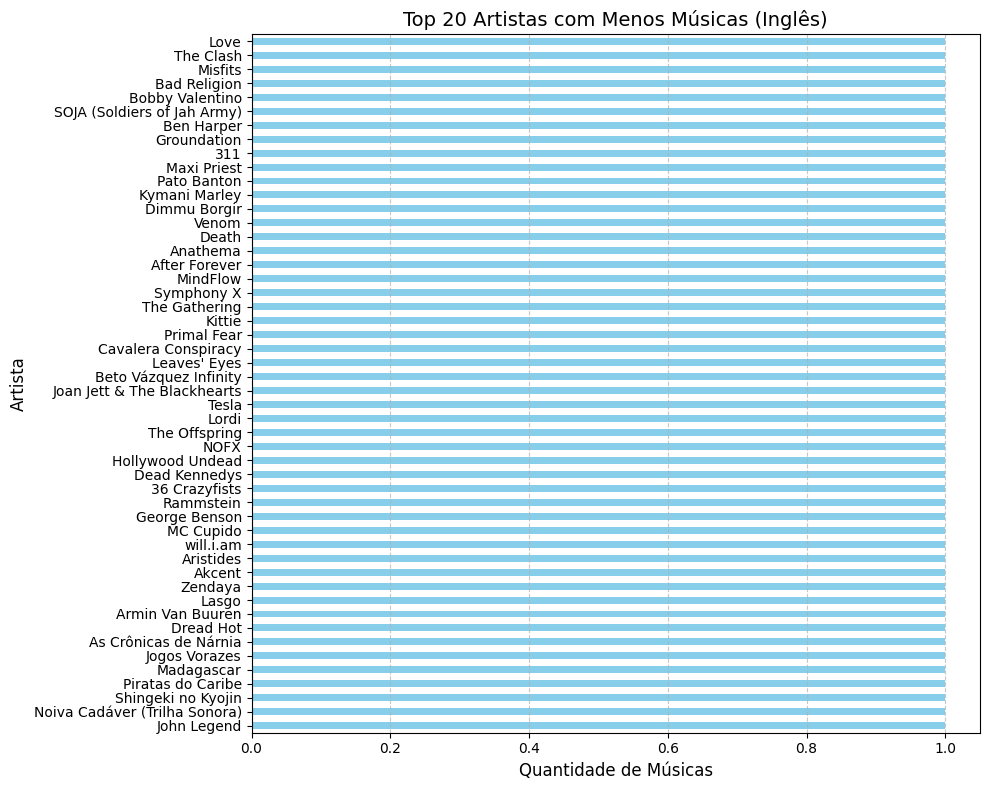

In [ ]:
import matplotlib.pyplot as plt

# 1. Pegar os 20 artistas com mais músicas
top_artistas = df_letras['Artist'].value_counts().tail(50)

# 2. Criar o gráfico
plt.figure(figsize=(10, 8))
top_artistas.plot(kind='barh', color='skyblue')

# 3. Customizar o visual
plt.title('Top 20 Artistas com Menos Músicas (Inglês)', fontsize=14)
plt.xlabel('Quantidade de Músicas', fontsize=12)
plt.ylabel('Artista', fontsize=12)
plt.gca().invert_yaxis() # Deixa o artista com MAIS músicas no topo
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Conta as músicas por artista
contagem = df_letras['Artist'].value_counts()

# 2. Seleciona apenas os nomes dos artistas que têm 30 ou mais músicas
artistas_mantidos = contagem[contagem >= 30].index

# 3. Filtra o DataFrame original mantendo apenas esses artistas
df_letras = df_letras[df_letras['Artist'].isin(artistas_mantidos)]

In [ ]:
df_letras

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres
0,Ivete Sangalo,/ivete-sangalo/,Arerê,/ivete-sangalo/arere.html,"Tudo o que eu quero nessa vida,\nToda vida, é\...",pt,4.4,Pop; Axé; Romântico
1,Ivete Sangalo,/ivete-sangalo/,Se Eu Não Te Amasse Tanto Assim,/ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...,Meu coração\nSem direção\nVoando só por voar\n...,pt,4.4,Pop; Axé; Romântico
2,Ivete Sangalo,/ivete-sangalo/,Céu da Boca,/ivete-sangalo/chupa-toda.html,É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...,pt,4.4,Pop; Axé; Romântico
3,Ivete Sangalo,/ivete-sangalo/,Quando A Chuva Passar,/ivete-sangalo/quando-a-chuva-passar.html,Quando a chuva passar\n\nPra quê falar\nSe voc...,pt,4.4,Pop; Axé; Romântico
4,Ivete Sangalo,/ivete-sangalo/,Sorte Grande,/ivete-sangalo/sorte-grande.html,A minha sorte grande foi você cair do céu\nMin...,pt,4.4,Pop; Axé; Romântico
...,...,...,...,...,...,...,...,...
379624,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 94 - Qualidades X Vícios,/xama-gideon-dos-lakotas/hino-94-qualidades-x-...,Se mantendo sempre com os braços cruzados\ne n...,pt,0.0,World Music
379625,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 95 - Percepção de Deus,/xama-gideon-dos-lakotas/hino-95-percepcao-de-...,"O homem atual, na grande maioria, é carente da...",pt,0.0,World Music
379626,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 96 - a Chave de Ser,/xama-gideon-dos-lakotas/hino-96-a-chave-de-se...,Esclarecimentos Maiores\nEntrego agora a chave...,pt,0.0,World Music
379627,Xamã Gideon dos Lakotas,/xama-gideon-dos-lakotas/,Hino 97 - Invocação,/xama-gideon-dos-lakotas/hino-97-invocacao.html,Invocação Eu Sou\nEu Sou a presença Divina Eu ...,pt,0.0,World Music


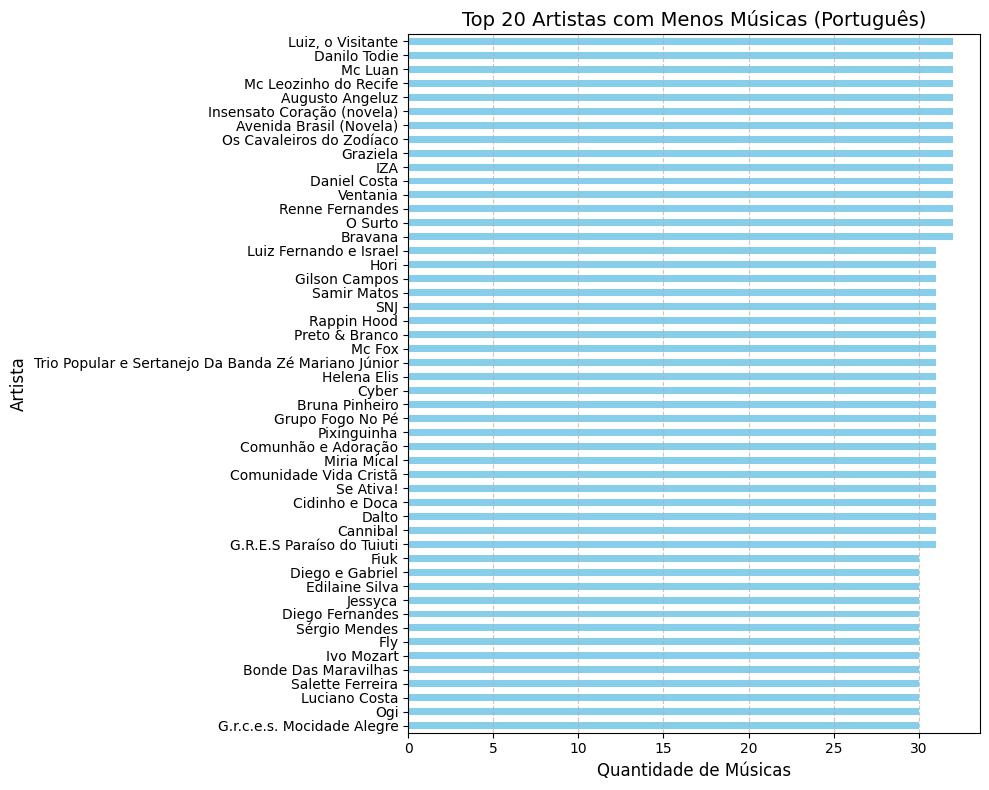

In [ ]:
import matplotlib.pyplot as plt

# 1. Pegar os 20 artistas com mais músicas
top_artistas = df_letras['Artist'].value_counts().tail(50)

# 2. Criar o gráfico
plt.figure(figsize=(10, 8))
top_artistas.plot(kind='barh', color='skyblue')

# 3. Customizar o visual
plt.title('Top 20 Artistas com Menos Músicas (Português)', fontsize=14)
plt.xlabel('Quantidade de Músicas', fontsize=12)
plt.ylabel('Artista', fontsize=12)
plt.gca().invert_yaxis() # Deixa o artista com MAIS músicas no topo
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df_letras = df_letras[df_letras['Popularity'] > 0]

In [ ]:
df_letras = df_letras.reset_index(drop=True)

In [ ]:
df_letras

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres
0,Ivete Sangalo,/ivete-sangalo/,Arerê,/ivete-sangalo/arere.html,"Tudo o que eu quero nessa vida,\nToda vida, é\...",pt,4.4,Pop; Axé; Romântico
1,Ivete Sangalo,/ivete-sangalo/,Se Eu Não Te Amasse Tanto Assim,/ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...,Meu coração\nSem direção\nVoando só por voar\n...,pt,4.4,Pop; Axé; Romântico
2,Ivete Sangalo,/ivete-sangalo/,Céu da Boca,/ivete-sangalo/chupa-toda.html,É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...,pt,4.4,Pop; Axé; Romântico
3,Ivete Sangalo,/ivete-sangalo/,Quando A Chuva Passar,/ivete-sangalo/quando-a-chuva-passar.html,Quando a chuva passar\n\nPra quê falar\nSe voc...,pt,4.4,Pop; Axé; Romântico
4,Ivete Sangalo,/ivete-sangalo/,Sorte Grande,/ivete-sangalo/sorte-grande.html,A minha sorte grande foi você cair do céu\nMin...,pt,4.4,Pop; Axé; Romântico
...,...,...,...,...,...,...,...,...
91743,Altemar Dutra,/altemar-dutra/,Você Era Assim,/altemar-dutra/voce-era-assim.html,Você era assim\nTão linda e inocente\nVocê era...,pt,1.4,Velha Guarda
91744,Altemar Dutra,/altemar-dutra/,Voltei a Te Encontrar,/altemar-dutra/voltei-a-te-encontrar.html,"Depois de caminhar, de tanto caminhar\nRolando...",pt,1.4,Velha Guarda
91745,Altemar Dutra,/altemar-dutra/,Voltei as Costas,/altemar-dutra/voltei-as-costas.html,Voltei as costas\nAo passado que foi triste\nE...,pt,1.4,Velha Guarda
91746,Altemar Dutra,/altemar-dutra/,Voltei Para Ficar,/altemar-dutra/voltei-para-ficar.html,"Voltei para ficar\nMeu bem o que passou, passo...",pt,1.4,Velha Guarda


In [ ]:
df_letras.value_counts('Genres').head(50)

,count
Genres,
Gospel/Religioso,12722
Sertanejo,6057
Sertanejo; Romântico,3309
MPB,3164
MPB; Romântico,2905
Romântico,2796
Forró,2626
Samba,1843
Romântico; Sertanejo; Country,1710


In [ ]:
# 1. Transforma a string "Pop; Axé" em uma lista ['Pop', 'Axé']
# 2. O 'explode' cria uma linha para cada item da lista
generos_individuais = df_letras['Genres'].str.split('; ').explode()

# 3. Agora contamos a frequência de cada um
frequencia_generos = generos_individuais.value_counts()

print(frequencia_generos.head(20)) # Mostra os 20 gêneros mais comuns

Genres
Romântico           30970
Gospel/Religioso    20350
MPB                 18670
Sertanejo           18028
Samba               10223
Pop/Rock             7795
Pop                  6815
Forró                6685
Rock                 6570
Pagode               6494
Country              4198
Infantil             3947
Axé                  3670
Rap                  3588
Trilha Sonora        3295
Hip Hop              2267
Reggae               2207
Bossa Nova           2149
Jovem Guarda         2052
COLETÂNEA            1987
Name: count, dtype: int64


# Claude


In [ ]:
API_KEY = "015ce67023c8f6c7673886e32ee2b87c"
BASE_URL = "http://ws.audioscrobbler.com/2.0/"

In [ ]:
def normalizar(texto):
    texto = texto.lower().strip()
    texto = re.sub(r"['\-]", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto

def get_track_info(artist, song, max_tags=5):
    def extrair(r):
        if "track" in r:
            track = r["track"]
            tags = [t["name"].lower() for t in track.get("toptags", {}).get("tag", [])[:max_tags]]
            return {
                "mbid": track.get("mbid", ""),
                "url": track.get("url", ""),
                "tags": tags
            }
        return None

    try:
        # Tentativa 1: nomes originais
        params = {
            "method": "track.getInfo",
            "artist": artist,
            "track": song,
            "api_key": API_KEY,
            "format": "json",
            "autocorrect": 1
        }
        r = requests.get(BASE_URL, params=params, timeout=10).json()
        resultado = extrair(r)
        if resultado and resultado["tags"]:
            return resultado

        # Tentativa 2: nomes normalizados
        params["artist"] = normalizar(artist)
        params["track"] = normalizar(song)
        r = requests.get(BASE_URL, params=params, timeout=10).json()
        resultado = extrair(r)
        if resultado and resultado["tags"]:
            return resultado

        # Tentativa 3: fallback para artista
        params3 = {
            "method": "artist.getTopTags",
            "artist": artist,
            "api_key": API_KEY,
            "format": "json",
            "autocorrect": 1
        }
        r = requests.get(BASE_URL, params=params3, timeout=10).json()
        if "toptags" in r and r["toptags"]["tag"]:
            tags = [t["name"].lower() for t in r["toptags"]["tag"][:max_tags]]
            return {"mbid": "", "url": "", "tags": tags}

        return {"mbid": "", "url": "", "tags": []}
    except:
        return {"mbid": "", "url": "", "tags": []}

In [ ]:
artist = df_letras['Artist'].iloc[0]
song = df_letras['SName'].iloc[0]

info = get_track_info(artist, song)
print(f"Artista: {artist}")
print(f"Música:  {song}")
print(f"MBID:    {info['mbid']}")
print(f"URL:     {info['url']}")
print(f"Tags:    {info['tags']}")

Artista: Ivete Sangalo
Música:  Arerê
MBID:    
URL:     
Tags:    ['axe', 'female vocalists', 'brazilian', 'mpb', 'pop']


###Shuffle

In [ ]:
df_letras = df_letras.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_letras.head())

                Artist                  ALink  \
0  Padre Antonio Maria  /padre-antonio-maria/   
1  Padre Fábio de Melo        /fabio-de-melo/   
2            Falamansa            /falamansa/   
3           Thiaguinho           /thiaguinho/   
4                Pollo                /pollo/   

                                           SName  \
0                            Minha Mãe Admirável   
1                                Milagre de Amor   
2                            Caminhos do Coração   
3                                    Se Der Rolo   
4  Fim de Semana na Quebrada (Part. Mc Pedrinho)   

                                               SLink  \
0      /padre-antonio-maria/minha-mae-admiravel.html   
1                /fabio-de-melo/milagre-de-amor.html   
2                /falamansa/caminhos-do-coracao.html   
3                       /thiaguinho/se-der-rolo.html   
4  /pollo/fim-de-semana-na-quebrada-part-mc-pedri...   

                                               Lyric la

In [ ]:
whitelist_br = {
    # --- MPB & Tradicional ---
    'mpb', 'musica popular brasileira', 'bossa nova', 'bossanova',
    'tropicalia', 'samba', 'samba-enredo', 'samba-cancao', 'pagode',
    'choro', 'chorinho', 'velha guarda',

    # --- Sertanejo & Regional ---
    'sertanejo', 'sertanejo universitario', 'sertanejo raiz', 'modao',
    'brazilian country', 'country', 'caipira',
    'forro', 'forró', 'xote', 'baiao', 'piseiro', 'pisadinha',
    'axe', 'axé', 'lambada', 'brega', 'tecnobrega', 'guarnice', 'frevo',

    # --- Rock & Alternativo ---
    'rock', 'rock nacional', 'rock brasil', 'rock brasileiro', 'pop rock',
    'indie', 'indie brasileiro', 'alternative rock', 'alternative',
    'punk', 'punk rock', 'hardcore', 'metal', 'heavy metal', 'thrash metal',
    'grunge', 'psychedelic rock', 'progressive rock',

    # --- Urbano & Pop ---
    'pop', 'pop brasileiro', 'dance', 'eurodance', 'synthpop',
    'funk', 'funk carioca', 'funk ostentacao', 'funk melody', 'baile funk',
    'hip hop', 'hip-hop', 'rap', 'rap nacional', 'trap', 'trap brasileiro',
    'r&b', 'soul', 'soul brasileiro', 'disco',

    # --- Carnaval & Festivo ---
    'carnaval', 'marchinha', 'marchinha de carnaval', 'pagode', 'pagode baiano',

    # --- Religioso & Outros ---
    'gospel', 'gospel brasil', 'louvor', 'religioso', 'musica catolica',
    'infantil', 'musica infantil', 'instrumental', 'violao', 'piano brasileiro',

    # --- Reggae & Outros ---
    'reggae', 'ska', 'dub', 'gospel', 'religioso', 'louvor', 'cristao',
    'infantil', 'kids', 'instrumental', 'violao', 'acoustic', 'acustico',
    'blues', 'jazz', 'latin', 'latin pop'
}

In [ ]:
def processar_e_filtrar(row):
    # Chama a sua função que já está pronta
    info = get_track_info(row['Artist'], row['SName'])

    # Lista de tags retornada pela API
    tags_da_api = info.get('tags', [])

    # Filtra usando a sua whitelist (certifique-se que ela está definida)
    filtradas = [t for t in tags_da_api if t in whitelist_br]

    # Se achou algo, retorna como string separada por "; "
    # Se não achou, retorna o valor original que já estava no DF (fallback)
    if filtradas:
        return "; ".join(filtradas)
    else:
        return None

# Fazendo a conversão do Genre em Genre_Updated (filtragem)

###Usado como teste de 50 linhas

In [ ]:
# Testando apenas nas primeiras 50 linhas para garantir que salva
#df_letras.loc[:50, 'Genres_Updated'] = df_letras.iloc[:50].apply(processar_e_filtrar, axis=1)

# Agora sim, remove o que a API/Filtro não encontrou em todo o dataset
#df_letras = df_letras.dropna(subset=['Genres_Updated']).reset_index(drop=True)

In [ ]:
df_letras

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres
0,Padre Antonio Maria,/padre-antonio-maria/,Minha Mãe Admirável,/padre-antonio-maria/minha-mae-admiravel.html,Minha mãe admirável\nMinha mãe eu sei que és\n...,pt,1.7,Gospel/Religioso
1,Padre Fábio de Melo,/fabio-de-melo/,Milagre de Amor,/fabio-de-melo/milagre-de-amor.html,Quando ergo meus olhos pro céu e minha voz se ...,pt,3.2,Gospel/Religioso; Romântico; Trilha Sonora
2,Falamansa,/falamansa/,Caminhos do Coração,/falamansa/caminhos-do-coracao.html,Há muito tempo que eu saí de casa\nHá muito te...,pt,1.8,Forró; Romântico
3,Thiaguinho,/thiaguinho/,Se Der Rolo,/thiaguinho/se-der-rolo.html,"Ei, confia cê sabe onde isso vai dar\nCê quer ...",pt,7.1,Pagode; Romântico; Samba
4,Pollo,/pollo/,Fim de Semana na Quebrada (Part. Mc Pedrinho),/pollo/fim-de-semana-na-quebrada-part-mc-pedri...,Fim de semana na quebrada\nFluxo a milhão\nSe ...,pt,1.8,Hip Hop; Rap; Romântico
...,...,...,...,...,...,...,...,...
91743,Ludmila Ferber,/ludmila-ferber/,Pra Me Alegrar,/ludmila-ferber/pra-me-alegrar.html,Eu não preciso de mais ilusão\nEu não preciso ...,pt,14.5,Gospel/Religioso; Country; Sertanejo
91744,João Bosco,/joao-bosco/,Enquanto O Inverno Nao Passar,/joao-bosco/enquanto-o-inverno-nao-passar.html,"O céu se fecha, o vento é frio, essa neblina\n...",pt,1.0,MPB; Samba
91745,Odair José,/odair-jose/,Bebo e Choro,/odair-jose/bebo-e-choro.html,Sobre a solidão da noite\nMe pegou de açoite a...,pt,1.5,Romântico
91746,É O Tchan,/e-o-tchan/,Samba Que Manda,/e-o-tchan/samba-que-manda.html,"Que requebrado é esse, gostoso\nQue criatura é...",pt,1.6,Axé


## Aplicando no df inteiro ☣

In [ ]:
!pip install tqdm

Criando a coluna que vai ficar os gêneros

In [ ]:
# 1. Verifique se a coluna existe. Se não existir, crie-a preenchida com nulos (NaN)
if 'Genres_Updated' not in df_letras.columns:
    df_letras['Genres_Updated'] = np.nan
    print("Coluna 'Genres_Updated' criada com sucesso.")

Coluna 'Genres_Updated' criada com sucesso.


In [ ]:
import os
from tqdm import tqdm

# 1. Definir o caminho da pasta
caminho_pasta = '/content/drive/MyDrive/Colab Notebooks/PLN Aulas'
arquivo_final = os.path.join(caminho_pasta, 'df_letras_processado.csv')

# 2. Garantir que a pasta existe (evita erro se houver erro de digitação no caminho)
if not os.path.exists(caminho_pasta):
    print(f"Erro: O caminho {caminho_pasta} não foi encontrado. Verifique se o Drive foi montado.")
else:
    print(f"Salvando progresso em: {arquivo_final}")

# 3. Loop de processamento com salvamento no Drive
LOTE_TAMANHO = 100

for i in tqdm(range(len(df_letras))):
    # Processa apenas se a linha ainda estiver vazia (permite continuar de onde parou)
    if pd.isna(df_letras.loc[i, 'Genres_Updated']):
        try:
            # Sua função de processamento
            resultado = processar_e_filtrar(df_letras.iloc[i])
            df_letras.at[i, 'Genres_Updated'] = resultado
        except Exception as e:
            print(f"Erro na linha {i}: {e}")
            continue

    # Salva no Drive a cada X linhas
    if (i + 1) % LOTE_TAMANHO == 0:
        df_letras.to_csv(arquivo_final, index=False)

# Salvamento definitivo ao final
df_letras.to_csv(arquivo_final, index=False)
print("Sucesso! O arquivo está seguro no seu Google Drive.")

Salvando progresso em: /content/drive/MyDrive/Colab Notebooks/PLN Aulas/df_letras_processado.csv


  0%|          | 1/91748 [00:00<8:04:06,  3.16it/s]/tmp/ipykernel_29339/3203606473.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'gospel' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_letras.at[i, 'Genres_Updated'] = resultado
 54%|█████▍    | 49719/91748 [5:14:56<3:06:13,  3.76it/s]

### Voltando após desconexão aos 54% (49719/91748)

In [ ]:
import pandas as pd
import numpy as np
import os
import requests
import time
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')
caminho_arquivo = '/content/drive/MyDrive/Colab Notebooks/PLN Aulas/df_letras_processado.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
API_KEY = "015ce67023c8f6c7673886e22ee2b87c"
BASE_URL = "https://ws.audioscrobbler.com/2.0/"

whitelist_br = {
    'rock', 'pop', 'samba', 'pagode', 'sertanejo', 'mpb', 'axe', 'axé', 'forro', 'forró',
    'piseiro', 'funk', 'rap', 'hip hop', 'reggae', 'gospel', 'indie', 'metal', 'bossa nova'
}

def get_track_info(artist, song):
    params = {"method": "track.getInfo", "artist": artist, "track": song, "api_key": API_KEY, "format": "json", "autocorrect": 1}
    try:
        r = requests.get(BASE_URL, params=params, timeout=10).json()
        if "track" in r and "toptags" in r["track"]:
            tags = [t["name"].lower() for t in r["track"]["toptags"].get("tag", [])]
            return {"tags": tags}
    except: pass
    return {"tags": []}

def processar_e_filtrar(row):
    info = get_track_info(row['Artist'], row['SName'])
    filtradas = [t for t in info['tags'] if t in whitelist_br]
    return "; ".join(filtradas) if filtradas else "SEM_TAG"

In [ ]:
# Carrega com low_memory=False para evitar o DtypeWarning e garantir integridade
df_letras = pd.read_csv(caminho_arquivo, low_memory=False)

# Limpeza dos nulos
df_letras['Genres_Updated'] = df_letras['Genres_Updated'].replace(['nan', 'NaN', 'None', '', 'nan; nan'], np.nan)

# VERIFICAÇÃO CRÍTICA: Se o número for menor que o seu backup, pare aqui!
print(f"Total de linhas no dataset: {len(df_letras)}")

indices_faltantes = df_letras[df_letras['Genres_Updated'].isna()].index
print(f"Faltam processar {len(indices_faltantes)} músicas.")

Total de linhas no dataset: 91748
Faltam processar 30241 músicas.


In [ ]:
df_letras

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres,Genres_Updated
0,Padre Antonio Maria,/padre-antonio-maria/,Minha Mãe Admirável,/padre-antonio-maria/minha-mae-admiravel.html,Minha mãe admirável\nMinha mãe eu sei que és\n...,pt,1.7,Gospel/Religioso,SEM_TAG
1,Padre Fábio de Melo,/fabio-de-melo/,Milagre de Amor,/fabio-de-melo/milagre-de-amor.html,Quando ergo meus olhos pro céu e minha voz se ...,pt,3.2,Gospel/Religioso; Romântico; Trilha Sonora,gospel
2,Falamansa,/falamansa/,Caminhos do Coração,/falamansa/caminhos-do-coracao.html,Há muito tempo que eu saí de casa\nHá muito te...,pt,1.8,Forró; Romântico,forro; xote
3,Thiaguinho,/thiaguinho/,Se Der Rolo,/thiaguinho/se-der-rolo.html,"Ei, confia cê sabe onde isso vai dar\nCê quer ...",pt,7.1,Pagode; Romântico; Samba,pagode; samba
4,Pollo,/pollo/,Fim de Semana na Quebrada (Part. Mc Pedrinho),/pollo/fim-de-semana-na-quebrada-part-mc-pedri...,Fim de semana na quebrada\nFluxo a milhão\nSe ...,pt,1.8,Hip Hop; Rap; Romântico,rap; hip hop
...,...,...,...,...,...,...,...,...,...
91743,Ludmila Ferber,/ludmila-ferber/,Pra Me Alegrar,/ludmila-ferber/pra-me-alegrar.html,Eu não preciso de mais ilusão\nEu não preciso ...,pt,14.5,Gospel/Religioso; Country; Sertanejo,NaN
91744,João Bosco,/joao-bosco/,Enquanto O Inverno Nao Passar,/joao-bosco/enquanto-o-inverno-nao-passar.html,"O céu se fecha, o vento é frio, essa neblina\n...",pt,1.0,MPB; Samba,NaN
91745,Odair José,/odair-jose/,Bebo e Choro,/odair-jose/bebo-e-choro.html,Sobre a solidão da noite\nMe pegou de açoite a...,pt,1.5,Romântico,NaN
91746,É O Tchan,/e-o-tchan/,Samba Que Manda,/e-o-tchan/samba-que-manda.html,"Que requebrado é esse, gostoso\nQue criatura é...",pt,1.6,Axé,NaN


In [ ]:
LOTE_TAMANHO = 100

# O loop usa os índices reais do DataFrame original
for i in tqdm(indices_faltantes):
    try:
        # Buscamos a info usando .loc para garantir que pegamos a linha certa do DF original
        resultado = processar_e_filtrar(df_letras.loc[i])

        # Gravamos o resultado no DataFrame principal
        df_letras.loc[i, 'Genres_Updated'] = resultado

        # O sleep é vital para o Drive e a API não "engasgarem"
        # time.sleep(0.1)

        # Salvamento periódico
        if (indices_faltantes.get_loc(i) + 1) % LOTE_TAMANHO == 0:
            # Salvamos o DF INTEIRO para garantir que as 91k linhas persistam
            df_letras.to_csv(caminho_arquivo, index=False)

    except Exception as e:
        print(f"Erro na linha {i}: {e}")
        continue

# Salvamento definitivo ao final
df_letras.to_csv(caminho_arquivo, index=False)
print("Tudo pronto e salvo com segurança!")

100%|██████████| 30241/30241 [1:11:27<00:00,  7.05it/s]


Tudo pronto e salvo com segurança!


In [ ]:
df_letras[48699:70000]

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres,Genres_Updated
48699,Timbalada,/timbalada/,Zorra,/timbalada/zorra-2.html,Zorra\n(Ninha Brito/Nem Cardoso)\n\nVou lhe mo...,pt,1.0,Axé,axe; samba
48700,Jerry Adriani,/jerry-adriani/,Calcei Sapatos Novos,/jerry-adriani/calcei-sapatos-novos.html,Calcei sapatos novos\n\nGuarda o que eu digo\n...,pt,0.3,Jovem Guarda,rock; pop
48701,Raquel Silva,/raquel-silva/,Velho Lar,/raquel-silva/velho-lar.html,Ainda vou te ver de volta ao seu lugar\nAinda ...,pt,1.0,Gospel/Religioso,SEM_TAG
48702,Israel e Rodolffo,/israel-e-rodolffo/,Ciscando E Batendo O Bico,/israel-e-rodolffo/ciscando-e-batendo-o-bico.html,"Eu agora to ""forgado""\nNada esquenta a minha t...",pt,1.6,Sertanejo; Romântico,SEM_TAG
48703,Anjos Anônimos,/anjos-anonimos/,Eu Choro Mais,/anjos-anonimos/xeroftalmia.html,Eu não choro mais\nPor quer eu não sinto seu p...,pt,0.1,Pop/Rock; Rock; Hardcore,SEM_TAG
...,...,...,...,...,...,...,...,...,...
69995,Legião Urbana,/legiao-urbana/,Os Anjos,/legiao-urbana/os-anjos-1.html,Hoje não dá\nHoje não dá\nNão sei mais o que d...,pt,14.8,Rock; Pop/Rock; MPB,SEM_TAG
69996,Trio Parada Dura,/trio-parada-dura/,Quero Falar com Alguém,/trio-parada-dura/quero-falar-com-alguem.html,Através dessa canção\nQue estou interpretando\...,pt,2.5,Sertanejo,SEM_TAG
69997,Elba Ramalho,/elba-ramalho/,Gaiola da Saudade,/elba-ramalho/gaiola-da-saudade.html,ELBA RAMALHO\n\nGAIOLA DA SAUDADE\n(Jam da Sil...,pt,3.4,Forró; MPB,SEM_TAG
69998,Igreja Cristã Maranata,/igreja-crista-maranata/,Jesus Meu Amigo,/igreja-crista-maranata/jesus-meu-amigo.html,. Jesus Meu Amigo\n\nJesus meu amigo morreu po...,pt,4.5,Gospel/Religioso,SEM_TAG


In [ ]:
print(f"O DataFrame ainda tem todas as linhas? {len(df_letras)}")
# O resultado DEVE ser 91748.

O DataFrame ainda tem todas as linhas? 91748


In [ ]:
print(df_letras['Genres_Updated'].value_counts(dropna=False))

Genres_Updated
SEM_TAG                                47841
gospel                                  3974
sertanejo; brazilian country            2650
mpb                                     2036
forro                                   1841
                                       ...  
pop; reggae                               16
pop; pop rock; rock; alternative          14
mpb; soul; funk                            1
alternative rock; rock                     1
rock; alternative; alternative rock        1
Name: count, Length: 224, dtype: int64


In [ ]:
generos_individuais = df_letras['Genres_Updated'].str.split('; ').explode()

frequencia_generos = generos_individuais.value_counts()

print(frequencia_generos.head(20)) # Mostra os 20 gêneros mais comuns

Genres_Updated
SEM_TAG              47841
mpb                  14840
sertanejo             8240
samba                 7487
gospel                7468
pop                   6106
rock                  4589
bossa nova            3547
pagode                3468
brazilian country     3415
forro                 3092
rap                   2015
brega                 1682
pop rock              1581
axe                   1486
caipira               1428
country               1330
reggae                1330
louvor                1320
funk                  1221
Name: count, dtype: int64


In [ ]:
df_letras.to_csv(caminho_arquivo, index=False)
print("Tudo pronto e salvo com segurança!")

Tudo pronto e salvo com segurança!


In [ ]:
df_letras[df_letras['Genres_Updated'] != 'SEM_TAG']

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres,Genres_Updated
1,Padre Fábio de Melo,/fabio-de-melo/,Milagre de Amor,/fabio-de-melo/milagre-de-amor.html,Quando ergo meus olhos pro céu e minha voz se ...,pt,3.2,Gospel/Religioso; Romântico; Trilha Sonora,gospel
2,Falamansa,/falamansa/,Caminhos do Coração,/falamansa/caminhos-do-coracao.html,Há muito tempo que eu saí de casa\nHá muito te...,pt,1.8,Forró; Romântico,forro; xote
3,Thiaguinho,/thiaguinho/,Se Der Rolo,/thiaguinho/se-der-rolo.html,"Ei, confia cê sabe onde isso vai dar\nCê quer ...",pt,7.1,Pagode; Romântico; Samba,pagode; samba
4,Pollo,/pollo/,Fim de Semana na Quebrada (Part. Mc Pedrinho),/pollo/fim-de-semana-na-quebrada-part-mc-pedri...,Fim de semana na quebrada\nFluxo a milhão\nSe ...,pt,1.8,Hip Hop; Rap; Romântico,rap; hip hop
5,Milton Nascimento,/milton-nascimento/,Gran Circo,/milton-nascimento/gran-circo.html,Vem chegando a lona suja\no grande circo human...,pt,11.3,MPB,mpb
...,...,...,...,...,...,...,...,...,...
49795,Mato Seco,/mato-seco/,Reggae E Flores,/mato-seco/reggae-e-flores.html,Admiração e outros sentimentos me conduzem a d...,pt,1.0,Reggae; Gospel/Religioso; Axé,reggae; ska
49796,Luiza Possi,/luiza-possi/,De Graça,/luiza-possi/de-graca.html,Eu gosto de você de graça\neu gosto de você a ...,pt,1.0,MPB; Romântico,mpb; pop
49797,Regis Danese,/regis-danese/,Jesus É o Meu Lar,/regis-danese/jesus-e-o-meu-lar.html,Eu sei tu as promessas não são só pra mim\nTen...,pt,2.8,Gospel/Religioso,gospel; pop
49798,Roberto Carlos,/roberto-carlos/,Todas as Manhãs,/roberto-carlos/todas-as-manhas.html,Todas as manhãs quando eu acordo eu me lembro ...,pt,49.1,Romântico; MPB; Jovem Guarda,mpb


In [ ]:
df_letras = df_letras[df_letras['Genres_Updated'] != 'SEM_TAG']

In [ ]:
df_letras

,Artist,ALink,SName,SLink,Lyric,language,Popularity,Genres,Genres_Updated
1,Padre Fábio de Melo,/fabio-de-melo/,Milagre de Amor,/fabio-de-melo/milagre-de-amor.html,Quando ergo meus olhos pro céu e minha voz se ...,pt,3.2,Gospel/Religioso; Romântico; Trilha Sonora,gospel
2,Falamansa,/falamansa/,Caminhos do Coração,/falamansa/caminhos-do-coracao.html,Há muito tempo que eu saí de casa\nHá muito te...,pt,1.8,Forró; Romântico,forro; xote
3,Thiaguinho,/thiaguinho/,Se Der Rolo,/thiaguinho/se-der-rolo.html,"Ei, confia cê sabe onde isso vai dar\nCê quer ...",pt,7.1,Pagode; Romântico; Samba,pagode; samba
4,Pollo,/pollo/,Fim de Semana na Quebrada (Part. Mc Pedrinho),/pollo/fim-de-semana-na-quebrada-part-mc-pedri...,Fim de semana na quebrada\nFluxo a milhão\nSe ...,pt,1.8,Hip Hop; Rap; Romântico,rap; hip hop
5,Milton Nascimento,/milton-nascimento/,Gran Circo,/milton-nascimento/gran-circo.html,Vem chegando a lona suja\no grande circo human...,pt,11.3,MPB,mpb
...,...,...,...,...,...,...,...,...,...
49795,Mato Seco,/mato-seco/,Reggae E Flores,/mato-seco/reggae-e-flores.html,Admiração e outros sentimentos me conduzem a d...,pt,1.0,Reggae; Gospel/Religioso; Axé,reggae; ska
49796,Luiza Possi,/luiza-possi/,De Graça,/luiza-possi/de-graca.html,Eu gosto de você de graça\neu gosto de você a ...,pt,1.0,MPB; Romântico,mpb; pop
49797,Regis Danese,/regis-danese/,Jesus É o Meu Lar,/regis-danese/jesus-e-o-meu-lar.html,Eu sei tu as promessas não são só pra mim\nTen...,pt,2.8,Gospel/Religioso,gospel; pop
49798,Roberto Carlos,/roberto-carlos/,Todas as Manhãs,/roberto-carlos/todas-as-manhas.html,Todas as manhãs quando eu acordo eu me lembro ...,pt,49.1,Romântico; MPB; Jovem Guarda,mpb


In [ ]:
df_letras = df_letras.drop(['ALink', 'SLink', 'language', 'Popularity', 'Genres'], axis=1)

In [ ]:
df_letras

,Artist,SName,Lyric,Genres_Updated
1,Padre Fábio de Melo,Milagre de Amor,Quando ergo meus olhos pro céu e minha voz se ...,gospel
2,Falamansa,Caminhos do Coração,Há muito tempo que eu saí de casa\nHá muito te...,forro; xote
3,Thiaguinho,Se Der Rolo,"Ei, confia cê sabe onde isso vai dar\nCê quer ...",pagode; samba
4,Pollo,Fim de Semana na Quebrada (Part. Mc Pedrinho),Fim de semana na quebrada\nFluxo a milhão\nSe ...,rap; hip hop
5,Milton Nascimento,Gran Circo,Vem chegando a lona suja\no grande circo human...,mpb
...,...,...,...,...
49795,Mato Seco,Reggae E Flores,Admiração e outros sentimentos me conduzem a d...,reggae; ska
49796,Luiza Possi,De Graça,Eu gosto de você de graça\neu gosto de você a ...,mpb; pop
49797,Regis Danese,Jesus É o Meu Lar,Eu sei tu as promessas não são só pra mim\nTen...,gospel; pop
49798,Roberto Carlos,Todas as Manhãs,Todas as manhãs quando eu acordo eu me lembro ...,mpb




---



In [ ]:
# Substitui todas as quebras de linha por um espaço em branco
df_letras['Lyric'] = df_letras['Lyric'].str.replace(r'\n', ' ', regex=True)

# Dica: Aproveite para remover espaços duplos que possam surgir
df_letras['Lyric'] = df_letras['Lyric'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
df_letras

,Artist,SName,Lyric,Genres_Updated
1,Padre Fábio de Melo,Milagre de Amor,Quando ergo meus olhos pro céu e minha voz se ...,gospel
2,Falamansa,Caminhos do Coração,Há muito tempo que eu saí de casa Há muito tem...,forro; xote
3,Thiaguinho,Se Der Rolo,"Ei, confia cê sabe onde isso vai dar Cê quer s...",pagode; samba
4,Pollo,Fim de Semana na Quebrada (Part. Mc Pedrinho),Fim de semana na quebrada Fluxo a milhão Se De...,rap; hip hop
5,Milton Nascimento,Gran Circo,Vem chegando a lona suja o grande circo humano...,mpb
...,...,...,...,...
49795,Mato Seco,Reggae E Flores,Admiração e outros sentimentos me conduzem a d...,reggae; ska
49796,Luiza Possi,De Graça,Eu gosto de você de graça eu gosto de você a t...,mpb; pop
49797,Regis Danese,Jesus É o Meu Lar,Eu sei tu as promessas não são só pra mim Tens...,gospel; pop
49798,Roberto Carlos,Todas as Manhãs,Todas as manhãs quando eu acordo eu me lembro ...,mpb


In [ ]:
df_letras.value_counts('Genres_Updated')

,count
Genres_Updated,
gospel,3974
sertanejo; brazilian country,2650
mpb,2036
forro,1841
sertanejo,1758
...,...
pop; reggae,16
pop; pop rock; rock; alternative,14
alternative rock; rock,1


In [ ]:
df_letras.to_csv(caminho_arquivo, index=False)
print("Tudo pronto e salvo com segurança!")



---



# Pré-processamento

In [ ]:
#Permissão para acessar algum arquivo do Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
stops = set(stopwords.words('portuguese'))


nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df_letras = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PLN Aulas/df_letras_processado.csv")

In [ ]:
df_letras

,Artist,SName,Lyric,Genres_Updated
0,Padre Fábio de Melo,Milagre de Amor,Quando ergo meus olhos pro céu e minha voz se ...,gospel
1,Falamansa,Caminhos do Coração,Há muito tempo que eu saí de casa Há muito tem...,forro; xote
2,Thiaguinho,Se Der Rolo,"Ei, confia cê sabe onde isso vai dar Cê quer s...",pagode; samba
3,Pollo,Fim de Semana na Quebrada (Part. Mc Pedrinho),Fim de semana na quebrada Fluxo a milhão Se De...,rap; hip hop
4,Milton Nascimento,Gran Circo,Vem chegando a lona suja o grande circo humano...,mpb
...,...,...,...,...
43902,Mato Seco,Reggae E Flores,Admiração e outros sentimentos me conduzem a d...,reggae; ska
43903,Luiza Possi,De Graça,Eu gosto de você de graça eu gosto de você a t...,mpb; pop
43904,Regis Danese,Jesus É o Meu Lar,Eu sei tu as promessas não são só pra mim Tens...,gospel; pop
43905,Roberto Carlos,Todas as Manhãs,Todas as manhãs quando eu acordo eu me lembro ...,mpb


###Limpeza das letras

In [ ]:
def limpar_lyric(texto):
    # Converte para string e coloca em minúsculas
    texto = str(texto).lower()

    # Substitui quebras de linha por espaços
    texto = texto.replace('\n', ' ')

    # Remove caracteres especiais e números (mantém letras acentuadas)
    texto = re.sub(r'[^a-záéíóúàèìòùâêîôûãõç\s]', '', texto)

    # Remove espaços múltiplos
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# Aplicação da limpeza na coluna Lyric
df_letras['lyric_limpo'] = df_letras['Lyric'].apply(limpar_lyric)

print("Exemplo do texto limpo:")
print(df_letras['lyric_limpo'].head())

Exemplo do texto limpo:
0    quando ergo meus olhos pro céu e minha voz se ...
1    há muito tempo que eu saí de casa há muito tem...
2    ei confia cê sabe onde isso vai dar cê quer se...
3    fim de semana na quebrada fluxo a milhão se de...
4    vem chegando a lona suja o grande circo humano...
Name: lyric_limpo, dtype: object


In [ ]:
df_letras

,Artist,SName,Lyric,Genres_Updated,lyric_limpo
0,Padre Fábio de Melo,Milagre de Amor,Quando ergo meus olhos pro céu e minha voz se ...,gospel,quando ergo meus olhos pro céu e minha voz se ...
1,Falamansa,Caminhos do Coração,Há muito tempo que eu saí de casa Há muito tem...,forro; xote,há muito tempo que eu saí de casa há muito tem...
2,Thiaguinho,Se Der Rolo,"Ei, confia cê sabe onde isso vai dar Cê quer s...",pagode; samba,ei confia cê sabe onde isso vai dar cê quer se...
3,Pollo,Fim de Semana na Quebrada (Part. Mc Pedrinho),Fim de semana na quebrada Fluxo a milhão Se De...,rap; hip hop,fim de semana na quebrada fluxo a milhão se de...
4,Milton Nascimento,Gran Circo,Vem chegando a lona suja o grande circo humano...,mpb,vem chegando a lona suja o grande circo humano...
...,...,...,...,...,...
43902,Mato Seco,Reggae E Flores,Admiração e outros sentimentos me conduzem a d...,reggae; ska,admiração e outros sentimentos me conduzem a d...
43903,Luiza Possi,De Graça,Eu gosto de você de graça eu gosto de você a t...,mpb; pop,eu gosto de você de graça eu gosto de você a t...
43904,Regis Danese,Jesus É o Meu Lar,Eu sei tu as promessas não são só pra mim Tens...,gospel; pop,eu sei tu as promessas não são só pra mim tens...
43905,Roberto Carlos,Todas as Manhãs,Todas as manhãs quando eu acordo eu me lembro ...,mpb,todas as manhãs quando eu acordo eu me lembro ...


### Tokenização e Remoção de Stopwords

In [ ]:
from nltk.corpus import stopwords
# Definição das stopwords em português
stops = set(stopwords.words('portuguese'))

def tokenizar_e_filtrar(texto):
    # Divide o texto em tokens (palavras)
    tokens = word_tokenize(texto)
    # Filtra as stopwords
    return [palavra for palavra in tokens if palavra not in stops]

# Criação da coluna com a lista de tokens filtrada
df_letras['tokens_final'] = df_letras['lyric_limpo'].apply(tokenizar_e_filtrar)

print("Exemplo de tokens após remoção de stopwords:")
print(df_letras['tokens_final'].head())

Exemplo de tokens após remoção de stopwords:
0    [ergo, olhos, pro, céu, voz, faz, canção, mila...
1    [tempo, saí, casa, tempo, caí, estrada, tempo,...
2    [ei, confia, cê, sabe, onde, vai, dar, cê, que...
3    [fim, semana, quebrada, fluxo, milhão, deus, q...
4    [vem, chegando, lona, suja, grande, circo, hum...
Name: tokens_final, dtype: object


In [ ]:
df_letras

,Artist,SName,Lyric,Genres_Updated,lyric_limpo,tokens_final
0,Padre Fábio de Melo,Milagre de Amor,Quando ergo meus olhos pro céu e minha voz se ...,gospel,quando ergo meus olhos pro céu e minha voz se ...,"[ergo, olhos, pro, céu, voz, faz, canção, mila..."
1,Falamansa,Caminhos do Coração,Há muito tempo que eu saí de casa Há muito tem...,forro; xote,há muito tempo que eu saí de casa há muito tem...,"[tempo, saí, casa, tempo, caí, estrada, tempo,..."
2,Thiaguinho,Se Der Rolo,"Ei, confia cê sabe onde isso vai dar Cê quer s...",pagode; samba,ei confia cê sabe onde isso vai dar cê quer se...,"[ei, confia, cê, sabe, onde, vai, dar, cê, que..."
3,Pollo,Fim de Semana na Quebrada (Part. Mc Pedrinho),Fim de semana na quebrada Fluxo a milhão Se De...,rap; hip hop,fim de semana na quebrada fluxo a milhão se de...,"[fim, semana, quebrada, fluxo, milhão, deus, q..."
4,Milton Nascimento,Gran Circo,Vem chegando a lona suja o grande circo humano...,mpb,vem chegando a lona suja o grande circo humano...,"[vem, chegando, lona, suja, grande, circo, hum..."
...,...,...,...,...,...,...
43902,Mato Seco,Reggae E Flores,Admiração e outros sentimentos me conduzem a d...,reggae; ska,admiração e outros sentimentos me conduzem a d...,"[admiração, outros, sentimentos, conduzem, diz..."
43903,Luiza Possi,De Graça,Eu gosto de você de graça eu gosto de você a t...,mpb; pop,eu gosto de você de graça eu gosto de você a t...,"[gosto, graça, gosto, toa, sempre, acho, porqu..."
43904,Regis Danese,Jesus É o Meu Lar,Eu sei tu as promessas não são só pra mim Tens...,gospel; pop,eu sei tu as promessas não são só pra mim tens...,"[sei, promessas, pra, mim, tens, plano, casa, ..."
43905,Roberto Carlos,Todas as Manhãs,Todas as manhãs quando eu acordo eu me lembro ...,mpb,todas as manhãs quando eu acordo eu me lembro ...,"[todas, manhãs, acordo, lembro, todos, momento..."


##Agrupando Gêneros

In [ ]:
mapa_generos = {
    # --- MPB & Samba ---
    'musica popular brasileira': 'mpb', 'tropicalia': 'mpb', 'bossa nova': 'mpb', 'bossanova': 'mpb',
    'samba-enredo': 'samba', 'samba-cancao': 'samba', 'velha guarda': 'samba',
    'choro': 'samba', 'chorinho': 'samba', 'pagode': 'samba', 'pagode baiano': 'samba',

    # --- Sertanejo & Forró ---
    'sertanejo universitario': 'sertanejo', 'sertanejo raiz': 'sertanejo', 'modao': 'sertanejo',
    'brazilian country': 'sertanejo', 'country': 'sertanejo', 'caipira': 'sertanejo',
    'xote': 'forro', 'baiao': 'forro', 'piseiro': 'forro', 'pisadinha': 'forro', 'forró': 'forro',

    # --- Rock & Metal ---
    'rock nacional': 'rock', 'rock brasil': 'rock', 'rock brasileiro': 'rock', 'pop rock': 'rock',
    'indie': 'rock', 'indie brasileiro': 'rock', 'alternative rock': 'rock', 'alternative': 'rock',
    'punk': 'rock', 'punk rock': 'rock', 'hardcore': 'rock', 'grunge': 'rock',
    'psychedelic rock': 'rock', 'progressive rock': 'rock',
    'metal': 'metal', 'heavy metal': 'metal', 'thrash metal': 'metal',

    # --- Urbano (Rap/Funk) ---
    'funk carioca': 'funk', 'funk ostentacao': 'funk', 'funk melody': 'funk', 'baile funk': 'funk',
    'hip-hop': 'hip hop', 'rap nacional': 'hip hop', 'rap': 'hip hop',
    'trap': 'hip hop', 'trap brasileiro': 'hip hop',

    # --- Pop & Dance ---
    'pop brasileiro': 'pop', 'latin pop': 'pop', 'dance': 'pop', 'eurodance': 'pop',
    'synthpop': 'pop', 'disco': 'pop', 'r&b': 'pop', 'soul': 'pop', 'soul brasileiro': 'pop',

    # --- Religioso ---
    'gospel brasil': 'gospel', 'louvor': 'gospel', 'religioso': 'gospel',
    'musica catolica': 'gospel', 'cristao': 'gospel',

    # --- Regional & Festivo ---
    'axe': 'axe', 'axé': 'axe', 'lambada': 'axe', 'brega': 'brega', 'tecnobrega': 'brega',
    'frevo': 'axe', 'carnaval': 'axe', 'marchinha': 'axe', 'marchinha de carnaval': 'axe',
    'guarnice': 'mpb',

    # --- Outros ---
    'reggae': 'reggae', 'ska': 'reggae', 'dub': 'reggae',
    'musica infantil': 'infantil', 'kids': 'infantil',
    'instrumental': 'instrumental', 'violao': 'instrumental', 'piano brasileiro': 'instrumental',
    'acoustic': 'instrumental', 'acustico': 'instrumental',
    'blues': 'blues_jazz', 'jazz': 'blues_jazz', 'latin': 'pop'
}

In [ ]:
# 1. Definição da função (Apenas ensina ao Python como fazer)
def consolidar_generos(lista):
    if not isinstance(lista, list):
        return []
    generos_limpos = set([mapa_generos.get(g, g) for g in lista])
    whitelist_final = {'mpb', 'samba', 'sertanejo', 'forro', 'rock', 'pop', 'funk', 'hip hop', 'axe', 'gospel', 'reggae'}
    return [g for g in generos_limpos if g in whitelist_final]

# 2. Preparação da coluna base (O split que estava faltando em cima)
df_letras['genre_list'] = df_letras['Genres_Updated'].str.split('; ')

# 3. Aplicação da função
df_letras['genre_list_final'] = df_letras['genre_list'].apply(consolidar_generos)

# 4. Criação do dataset de modelagem (Removendo vazios)
df_modelagem = df_letras[df_letras['genre_list_final'].map(len) > 0].copy()

# 5. Verificação
print(f"Total de músicas para modelagem: {len(df_modelagem)}")
display(df_modelagem[['Genres_Updated', 'genre_list_final']].head())

Total de músicas para modelagem: 43626


,Genres_Updated,genre_list_final
0,gospel,[gospel]
1,forro; xote,[forro]
2,pagode; samba,[samba]
3,rap; hip hop,[hip hop]
4,mpb,[mpb]


In [ ]:
df_modelagem = df_modelagem.reset_index()

In [ ]:
df_modelagem

,index,Artist,SName,Lyric,Genres_Updated,lyric_limpo,tokens_final,genre_list,genre_list_final
0,0,Padre Fábio de Melo,Milagre de Amor,Quando ergo meus olhos pro céu e minha voz se ...,gospel,quando ergo meus olhos pro céu e minha voz se ...,"[ergo, olhos, pro, céu, voz, faz, canção, mila...",[gospel],[gospel]
1,1,Falamansa,Caminhos do Coração,Há muito tempo que eu saí de casa Há muito tem...,forro; xote,há muito tempo que eu saí de casa há muito tem...,"[tempo, saí, casa, tempo, caí, estrada, tempo,...","[forro, xote]",[forro]
2,2,Thiaguinho,Se Der Rolo,"Ei, confia cê sabe onde isso vai dar Cê quer s...",pagode; samba,ei confia cê sabe onde isso vai dar cê quer se...,"[ei, confia, cê, sabe, onde, vai, dar, cê, que...","[pagode, samba]",[samba]
3,3,Pollo,Fim de Semana na Quebrada (Part. Mc Pedrinho),Fim de semana na quebrada Fluxo a milhão Se De...,rap; hip hop,fim de semana na quebrada fluxo a milhão se de...,"[fim, semana, quebrada, fluxo, milhão, deus, q...","[rap, hip hop]",[hip hop]
4,4,Milton Nascimento,Gran Circo,Vem chegando a lona suja o grande circo humano...,mpb,vem chegando a lona suja o grande circo humano...,"[vem, chegando, lona, suja, grande, circo, hum...",[mpb],[mpb]
...,...,...,...,...,...,...,...,...,...
43621,43902,Mato Seco,Reggae E Flores,Admiração e outros sentimentos me conduzem a d...,reggae; ska,admiração e outros sentimentos me conduzem a d...,"[admiração, outros, sentimentos, conduzem, diz...","[reggae, ska]",[reggae]
43622,43903,Luiza Possi,De Graça,Eu gosto de você de graça eu gosto de você a t...,mpb; pop,eu gosto de você de graça eu gosto de você a t...,"[gosto, graça, gosto, toa, sempre, acho, porqu...","[mpb, pop]","[mpb, pop]"
43623,43904,Regis Danese,Jesus É o Meu Lar,Eu sei tu as promessas não são só pra mim Tens...,gospel; pop,eu sei tu as promessas não são só pra mim tens...,"[sei, promessas, pra, mim, tens, plano, casa, ...","[gospel, pop]","[pop, gospel]"
43624,43905,Roberto Carlos,Todas as Manhãs,Todas as manhãs quando eu acordo eu me lembro ...,mpb,todas as manhãs quando eu acordo eu me lembro ...,"[todas, manhãs, acordo, lembro, todos, momento...",[mpb],[mpb]


In [ ]:
contagem_generos = df_modelagem['genre_list_final'].explode().value_counts()

print("--- Distribuição dos Gêneros Consolidados ---")
print(contagem_generos)

print("\n--- Distribuição em % ---")
print(df_modelagem['genre_list_final'].explode().value_counts(normalize=True) * 100)

--- Distribuição dos Gêneros Consolidados ---
genre_list_final
mpb          15072
sertanejo     8524
pop           7639
samba         7630
gospel        7468
rock          6140
forro         3130
hip hop       2189
axe           2088
reggae        1348
funk          1245
Name: count, dtype: int64

--- Distribuição em % ---
genre_list_final
mpb          24.125622
sertanejo    13.644294
pop          12.227682
samba        12.213276
gospel       11.953964
rock          9.828246
forro         5.010164
hip hop       3.503914
axe           3.342244
reggae        2.157732
funk          1.992861
Name: proportion, dtype: float64


## Binarização dos Gêneros

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

# Instanciamos e aplicamos o binarizador
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df_modelagem['genre_list_final'])

# Agora y é uma matriz onde cada coluna representa um gênero (ex: mpb, rock, samba...)
print(f"Total de classes identificadas: {len(mlb.classes_)}")
print(f"Classes: {mlb.classes_}")

Total de classes identificadas: 11
Classes: ['axe' 'forro' 'funk' 'gospel' 'hip hop' 'mpb' 'pop' 'reggae' 'rock'
 'samba' 'sertanejo']


# Stemming

In [ ]:
from nltk.stem import RSLPStemmer
import nltk
nltk.download('rslp')

stemmer = RSLPStemmer()

def aplicar_stemming(texto):
    # Stemming funciona melhor em palavras individuais
    return " ".join([stemmer.stem(palavra) for palavra in texto.split()])

df_modelagem['lyric_stemmed'] = df_modelagem['lyric_limpo'].apply(aplicar_stemming)

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


In [ ]:
df_modelagem

,index,Artist,SName,Lyric,Genres_Updated,lyric_limpo,tokens_final,genre_list,genre_list_final,lyric_stemmed
0,0,Padre Fábio de Melo,Milagre de Amor,Quando ergo meus olhos pro céu e minha voz se ...,gospel,quando ergo meus olhos pro céu e minha voz se ...,"[ergo, olhos, pro, céu, voz, faz, canção, mila...",[gospel],[gospel],qu erg meu olh pro céu e minh voz se faz cançã...
1,1,Falamansa,Caminhos do Coração,Há muito tempo que eu saí de casa Há muito tem...,forro; xote,há muito tempo que eu saí de casa há muito tem...,"[tempo, saí, casa, tempo, caí, estrada, tempo,...","[forro, xote]",[forro],há muit temp que eu saí de cas há muit temp qu...
2,2,Thiaguinho,Se Der Rolo,"Ei, confia cê sabe onde isso vai dar Cê quer s...",pagode; samba,ei confia cê sabe onde isso vai dar cê quer se...,"[ei, confia, cê, sabe, onde, vai, dar, cê, que...","[pagode, samba]",[samba],ei conf cê sab ond iss vai dar cê qu ser feliz...
3,3,Pollo,Fim de Semana na Quebrada (Part. Mc Pedrinho),Fim de semana na quebrada Fluxo a milhão Se De...,rap; hip hop,fim de semana na quebrada fluxo a milhão se de...,"[fim, semana, quebrada, fluxo, milhão, deus, q...","[rap, hip hop]",[hip hop],fim de seman na quebr flux a milhã se deu quis...
4,4,Milton Nascimento,Gran Circo,Vem chegando a lona suja o grande circo humano...,mpb,vem chegando a lona suja o grande circo humano...,"[vem, chegando, lona, suja, grande, circo, hum...",[mpb],[mpb],vem cheg a lon suj o grand circ human com a fo...
...,...,...,...,...,...,...,...,...,...,...
43621,43902,Mato Seco,Reggae E Flores,Admiração e outros sentimentos me conduzem a d...,reggae; ska,admiração e outros sentimentos me conduzem a d...,"[admiração, outros, sentimentos, conduzem, diz...","[reggae, ska]",[reggae],admir e outr sent me conduz a diz a ra porqu d...
43622,43903,Luiza Possi,De Graça,Eu gosto de você de graça eu gosto de você a t...,mpb; pop,eu gosto de você de graça eu gosto de você a t...,"[gosto, graça, gosto, toa, sempre, acho, porqu...","[mpb, pop]","[mpb, pop]",eu gost de voc de graç eu gost de voc a toa eu...
43623,43904,Regis Danese,Jesus É o Meu Lar,Eu sei tu as promessas não são só pra mim Tens...,gospel; pop,eu sei tu as promessas não são só pra mim tens...,"[sei, promessas, pra, mim, tens, plano, casa, ...","[gospel, pop]","[pop, gospel]",eu sei tu as promess não são só pra mim tem um...
43624,43905,Roberto Carlos,Todas as Manhãs,Todas as manhãs quando eu acordo eu me lembro ...,mpb,todas as manhãs quando eu acordo eu me lembro ...,"[todas, manhãs, acordo, lembro, todos, momento...",[mpb],[mpb],tod as manhã qu eu acord eu me lembr de voc to...


In [ ]:
df_modelagem

,index,Artist,SName,Lyric,Genres_Updated,lyric_limpo,tokens_final,genre_list,genre_list_final,lyric_stemmed,tokens_stemmed
0,0,Padre Fábio de Melo,Milagre de Amor,Quando ergo meus olhos pro céu e minha voz se ...,gospel,quando ergo meus olhos pro céu e minha voz se ...,"[ergo, olhos, pro, céu, voz, faz, canção, mila...",[gospel],[gospel],qu erg meu olh pro céu e minh voz se faz cançã...,"[erg, olh, pro, céu, voz, faz, cançã, milagr, ..."
1,1,Falamansa,Caminhos do Coração,Há muito tempo que eu saí de casa Há muito tem...,forro; xote,há muito tempo que eu saí de casa há muito tem...,"[tempo, saí, casa, tempo, caí, estrada, tempo,...","[forro, xote]",[forro],há muit temp que eu saí de cas há muit temp qu...,"[temp, saí, cas, temp, caí, estr, temp, vid, a..."
2,2,Thiaguinho,Se Der Rolo,"Ei, confia cê sabe onde isso vai dar Cê quer s...",pagode; samba,ei confia cê sabe onde isso vai dar cê quer se...,"[ei, confia, cê, sabe, onde, vai, dar, cê, que...","[pagode, samba]",[samba],ei conf cê sab ond iss vai dar cê qu ser feliz...,"[ei, conf, cê, sab, ond, vai, dar, cê, qu, fel..."
3,3,Pollo,Fim de Semana na Quebrada (Part. Mc Pedrinho),Fim de semana na quebrada Fluxo a milhão Se De...,rap; hip hop,fim de semana na quebrada fluxo a milhão se de...,"[fim, semana, quebrada, fluxo, milhão, deus, q...","[rap, hip hop]",[hip hop],fim de seman na quebr flux a milhã se deu quis...,"[fim, seman, quebr, flux, milhã, deu, quis, pe..."
4,4,Milton Nascimento,Gran Circo,Vem chegando a lona suja o grande circo humano...,mpb,vem chegando a lona suja o grande circo humano...,"[vem, chegando, lona, suja, grande, circo, hum...",[mpb],[mpb],vem cheg a lon suj o grand circ human com a fo...,"[vem, cheg, lon, suj, grand, circ, human, fom,..."
...,...,...,...,...,...,...,...,...,...,...,...
43621,43902,Mato Seco,Reggae E Flores,Admiração e outros sentimentos me conduzem a d...,reggae; ska,admiração e outros sentimentos me conduzem a d...,"[admiração, outros, sentimentos, conduzem, diz...","[reggae, ska]",[reggae],admir e outr sent me conduz a diz a ra porqu d...,"[admir, outr, sent, conduz, diz, ra, porqu, de..."
43622,43903,Luiza Possi,De Graça,Eu gosto de você de graça eu gosto de você a t...,mpb; pop,eu gosto de você de graça eu gosto de você a t...,"[gosto, graça, gosto, toa, sempre, acho, porqu...","[mpb, pop]","[mpb, pop]",eu gost de voc de graç eu gost de voc a toa eu...,"[gost, graç, gost, toa, sempr, ach, porqu, dei..."
43623,43904,Regis Danese,Jesus É o Meu Lar,Eu sei tu as promessas não são só pra mim Tens...,gospel; pop,eu sei tu as promessas não são só pra mim tens...,"[sei, promessas, pra, mim, tens, plano, casa, ...","[gospel, pop]","[pop, gospel]",eu sei tu as promess não são só pra mim tem um...,"[sei, promess, pra, mim, tem, plan, cas, temp,..."
43624,43905,Roberto Carlos,Todas as Manhãs,Todas as manhãs quando eu acordo eu me lembro ...,mpb,todas as manhãs quando eu acordo eu me lembro ...,"[todas, manhãs, acordo, lembro, todos, momento...",[mpb],[mpb],tod as manhã qu eu acord eu me lembr de voc to...,"[tod, manhã, acord, lembr, tod, moment, dia, c..."


In [ ]:
# Salvamento definitivo ao final
df_modelagem.to_csv('/content/drive/MyDrive/Colab Notebooks/PLN Aulas/df_pre_divisao.csv', index=False)
print("Tudo pronto e salvo com segurança!")

Tudo pronto e salvo com segurança!


## Separação do DF em treino e teste

In [ ]:
from sklearn.model_selection import train_test_split

X = df_modelagem['lyric_stemmed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 34900 amostras
Teste: 8726 amostras


###Vetorização com TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Criamos o vetorizador (Dica: use ngram_range para pegar expressões de 2 palavras)
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 4))

# APRENDE com o treino e TRANSFORMA o treino
X_train_tfidf = tfidf.fit_transform(X_train)

# APENAS TRANSFORMA o teste (usando o que aprendeu no treino)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
joblib.dump(tfidf, '/content/drive/MyDrive/Colab Notebooks/PLN Aulas/tfidf_50k_050.pkl')

['/content/drive/MyDrive/Colab Notebooks/PLN Aulas/tfidf_50k_050.pkl']

#Teste Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# 1. Definindo o modelo com pesos balanceados
# O 'max_iter' maior garante que o modelo tenha tempo de convergir em textos longos
clf_baseline = OneVsRestClassifier(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)

# 2. Treinando com os seus dados TF-IDF
clf_baseline.fit(X_train_tfidf, y_train)

# 3. Avaliando
y_pred = clf_baseline.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

              precision    recall  f1-score   support

         axe       0.24      0.54      0.33       412
       forro       0.34      0.59      0.43       675
        funk       0.24      0.45      0.32       239
      gospel       0.87      0.90      0.88      1451
     hip hop       0.61      0.72      0.66       486
         mpb       0.65      0.76      0.70      3066
         pop       0.30      0.46      0.36      1521
      reggae       0.25      0.40      0.31       266
        rock       0.35      0.58      0.44      1233
       samba       0.41      0.65      0.50      1509
   sertanejo       0.52      0.76      0.62      1645

   micro avg       0.47      0.68      0.56     12503
   macro avg       0.43      0.62      0.50     12503
weighted avg       0.51      0.68      0.58     12503
 samples avg       0.53      0.71      0.57     12503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


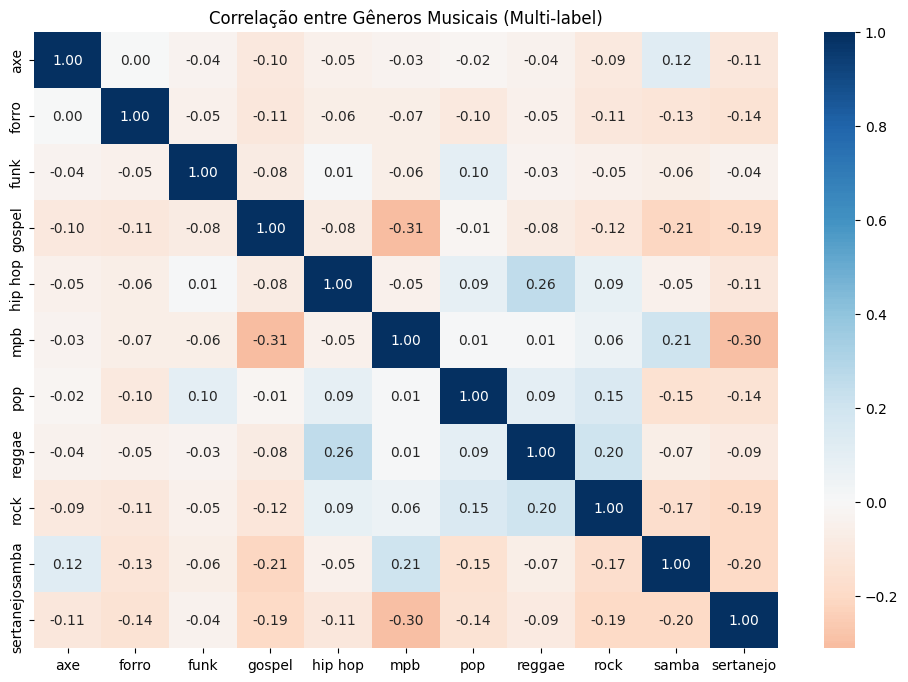

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Criamos um DataFrame com a matriz binarizada (y) e o nome dos gêneros
df_corr = pd.DataFrame(y, columns=mlb.classes_)

# 2. Calculamos a correlação (Pearson é o padrão)
corr_matrix = df_corr.corr()

# 3. Plotamos o Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Correlação entre Gêneros Musicais (Multi-label)')
plt.show()

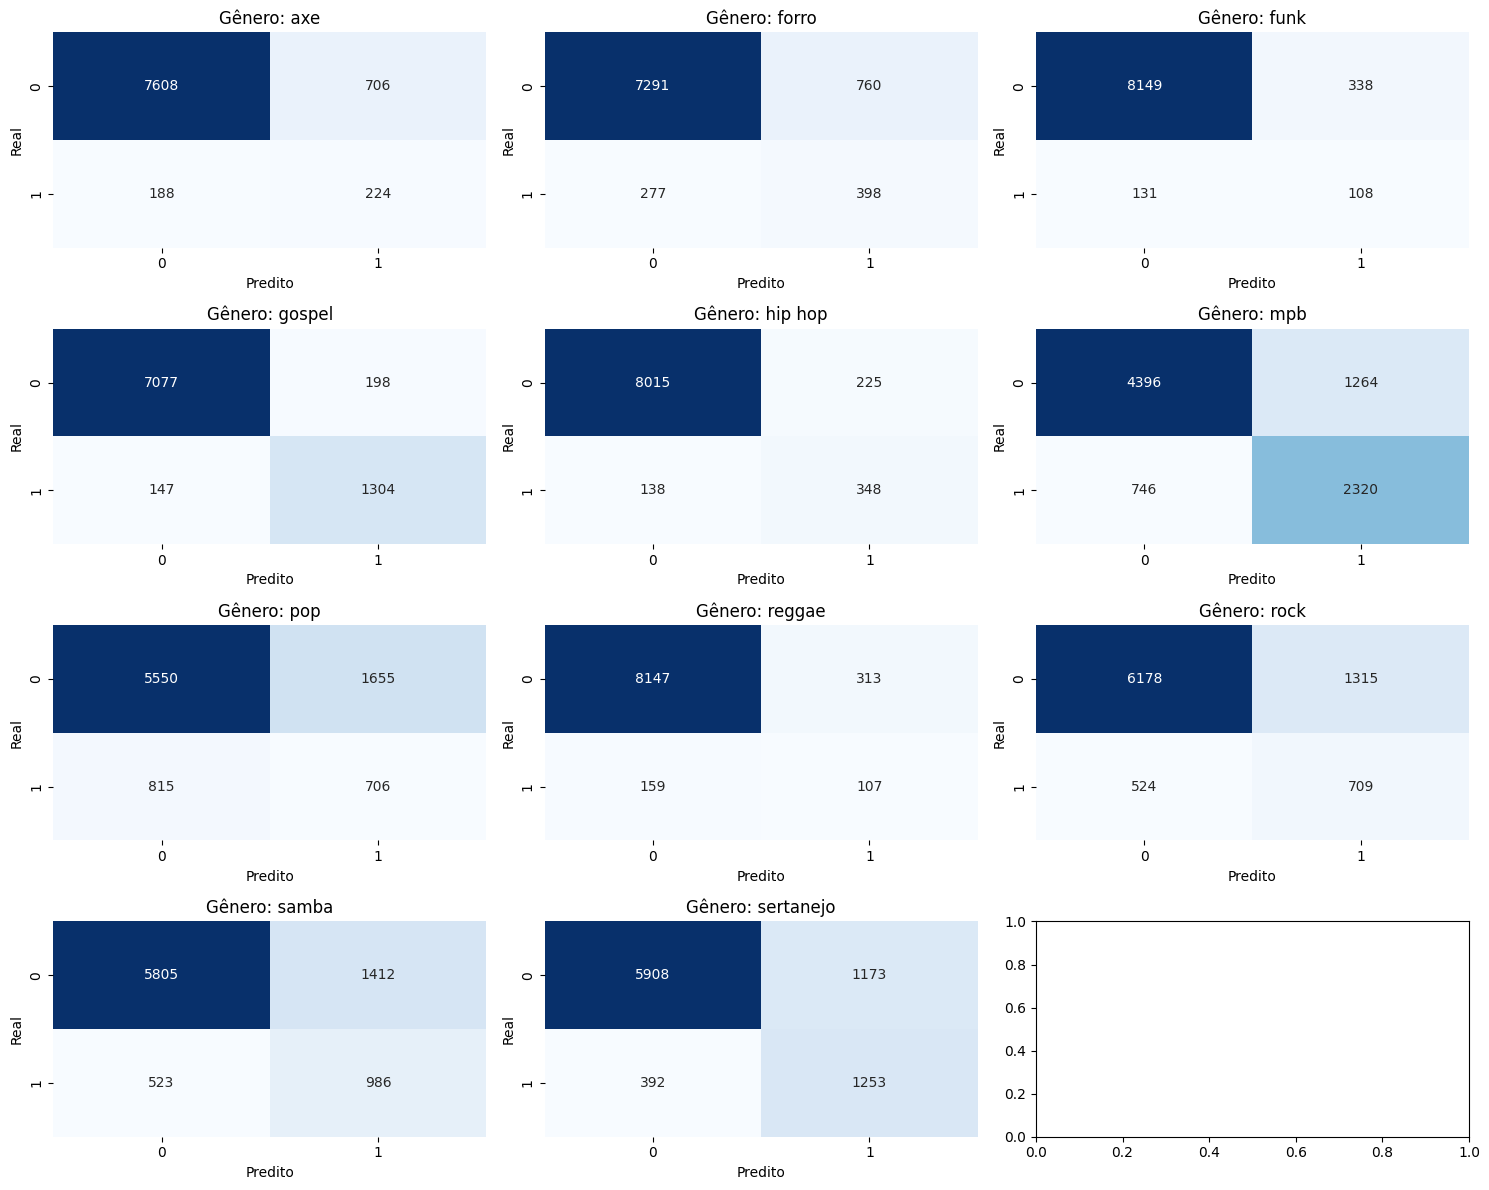

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

# 1. Gera as matrizes para cada gênero (retorna um array de matrizes 2x2)
matrices = multilabel_confusion_matrix(y_test, y_pred)

# 2. Configura o visual (vamos plotar as 11 matrizes em uma grade)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, (matrix, genre) in enumerate(zip(matrices, mlb.classes_)):
    sns.heatmap(matrix, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'Gênero: {genre}')
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')

# Remove os eixos vazios (já que temos 11 gêneros e 12 espaços na grade)
plt.tight_layout()
plt.show()

# Teste Naive Bayes

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB

# OneVsRest treina um classificador para cada gênero
modelo_nb = OneVsRestClassifier(MultinomialNB())
modelo_nb.fit(X_train_tfidf, y_train)

# Predição
y_pred = modelo_nb.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import classification_report, hamming_loss

# 1. Faz as predições no conjunto de teste
y_pred = modelo_nb.predict(X_test_tfidf)

# 2. Gera o relatório (usando os nomes das classes do binarizador)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

              precision    recall  f1-score   support

         axe       0.33      0.00      0.00       412
       forro       0.56      0.01      0.01       675
        funk       0.00      0.00      0.00       239
      gospel       0.92      0.76      0.83      1451
     hip hop       0.62      0.01      0.02       486
         mpb       0.76      0.38      0.51      3066
         pop       0.25      0.00      0.01      1521
      reggae       0.00      0.00      0.00       266
        rock       0.25      0.00      0.00      1233
       samba       0.73      0.04      0.08      1509
   sertanejo       0.88      0.14      0.25      1645

   micro avg       0.83      0.21      0.33     12503
   macro avg       0.48      0.12      0.16     12503
weighted avg       0.62      0.21      0.27     12503
 samples avg       0.29      0.23      0.25     12503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
joblib.dump(modelo_nb, 'modelo_naive_bayes_50k.pkl')

['modelo_naive_bayes_50k.pkl']

###Vetorização com Word2Vec

In [ ]:
!pip install gensim

In [ ]:
import nltk
from nltk.stem import RSLPStemmer

# 1. Garanta que o recurso está baixado e o stemmer inicializado
nltk.download('rslp')
stemmer = RSLPStemmer()

# 2. Função para aplicar em cada lista de tokens
def stem_lista(lista_tokens):
    # Retorna uma nova lista com os radicais de cada palavra
    return [stemmer.stem(palavra) for palavra in lista_tokens]

# 3. Criando a nova coluna com os radicais
df_modelagem['tokens_stemmed'] = df_modelagem['tokens_final'].apply(stem_lista)

# Visualizando o resultado
print(df_modelagem[['tokens_final', 'tokens_stemmed']].head())

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


                                        tokens_final  \
0  [ergo, olhos, pro, céu, voz, faz, canção, mila...   
1  [tempo, saí, casa, tempo, caí, estrada, tempo,...   
2  [ei, confia, cê, sabe, onde, vai, dar, cê, que...   
3  [fim, semana, quebrada, fluxo, milhão, deus, q...   
4  [vem, chegando, lona, suja, grande, circo, hum...   

                                      tokens_stemmed  
0  [erg, olh, pro, céu, voz, faz, cançã, milagr, ...  
1  [temp, saí, cas, temp, caí, estr, temp, vid, a...  
2  [ei, conf, cê, sab, ond, vai, dar, cê, qu, fel...  
3  [fim, seman, quebr, flux, milhã, deu, quis, pe...  
4  [vem, cheg, lon, suj, grand, circ, human, fom,...  


In [ ]:
from gensim.models import Word2Vec
import numpy as np

# 1. Pegamos a coluna de tokens (que deve ser uma lista de listas)
sentencas = df_modelagem['tokens_stemmed'].tolist()

# 2. Treinamos o modelo
# vector_size=100: cada palavra vira um vetor de 100 números
# window=5: olha 5 palavras para trás e 5 para frente
# min_count=2: ignora palavras que aparecem apenas 1 vez no dataset todo
modelo_w2v = Word2Vec(sentences=sentencas, vector_size=100, window=5, min_count=2, workers=4)

# Para ver o vetor de uma palavra específica:
# print(modelo_w2v.wv['amor'])

In [ ]:
# Função para vetorizar uma única lista de tokens
def vetorizar_musica(tokens, modelo):
    vetores = [modelo.wv[word] for word in tokens if word in modelo.wv]
    if len(vetores) > 0:
        return np.mean(vetores, axis=0)
    return None # Retorna None se não houver palavras conhecidas

# Criamos uma série temporária
series_w2v = df_modelagem['tokens_stemmed'].apply(lambda t: vetorizar_musica(t, modelo_w2v))

# Agora filtramos o DataFrame original para remover apenas onde a vetorização falhou
# Isso garante que df_final e X_w2v tenham o mesmo tamanho
df_final = df_modelagem[series_w2v.notna()].copy()
X_w2v = np.array(series_w2v.dropna().tolist())

print(f"Novo tamanho de X: {X_w2v.shape[0]}")

Novo tamanho de X: 43626


In [ ]:
# Binariza apenas as linhas que sobreviveram
y = mlb.transform(df_final['genre_list_final'])

print(f"Novo tamanho de y: {y.shape[0]}")
# Agora os dois números devem ser IGUAIS (ex: 43626)

Novo tamanho de y: 43626


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Split (Lembre-se: use o mesmo random_state para comparar com o TF-IDF!)
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42
)


# Treino (Naive Bayes NÃO funciona aqui, use Logistic Regression)
clf_w2v = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=2000))
clf_w2v.fit(X_train_w2v, y_train)

# Resultado
y_pred_w2v = clf_w2v.predict(X_test_w2v)
print(classification_report(y_test, y_pred_w2v, target_names=mlb.classes_))

              precision    recall  f1-score   support

         axe       0.13      0.73      0.22       412
       forro       0.17      0.73      0.28       675
        funk       0.07      0.71      0.13       239
      gospel       0.80      0.91      0.85      1451
     hip hop       0.17      0.74      0.28       486
         mpb       0.56      0.74      0.64      3066
         pop       0.23      0.59      0.34      1521
      reggae       0.06      0.67      0.12       266
        rock       0.24      0.69      0.36      1233
       samba       0.28      0.70      0.40      1509
   sertanejo       0.37      0.74      0.50      1645

   micro avg       0.28      0.73      0.41     12503
   macro avg       0.28      0.72      0.37     12503
weighted avg       0.39      0.73      0.48     12503
 samples avg       0.34      0.75      0.43     12503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Teste Random Forest

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Tenha certeza de que está usando o DataFrame que contém as 11 classes consolidadas
# Vamos reconstruir o X (texto) e o y (matriz binária) do zero para alinhar
X_texto = df_modelagem['lyric_stemmed']
y_binario = mlb.transform(df_modelagem['genre_list_final'])

# 2. Refaça o Split (Isso garante que X e y tenham o mesmo número de linhas)
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_texto, y_binario, test_size=0.2, random_state=42
)

# 3. Agora aplique o TF-IDF APENAS no resultado desse split
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf = tfidf.transform(X_test_txt)

# Verificação de segurança: os dois números DEVEM ser iguais agora
print(f"Linhas no X_train_tfidf: {X_train_tfidf.shape[0]}")
print(f"Linhas no y_train: {y_train.shape[0]}")

Linhas no X_train_tfidf: 34900
Linhas no y_train: 34900


In [ ]:
joblib.dump(tfidf, '/content/drive/MyDrive/Colab Notebooks/PLN Aulas/tfidf_5k_050.pkl')

['/content/drive/MyDrive/Colab Notebooks/PLN Aulas/tfidf_5k_050.pkl']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# 1. Definindo o modelo
# n_estimators=200: Usaremos 200 árvores para decidir o gênero
# n_jobs=-1: Usa todos os núcleos do processador do Colab (mais rápido)
# class_weight='balanced': Essencial para não ignorar o Funk/Reggae
clf_rf = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=200, n_jobs=-1, class_weight='balanced', random_state=42)
)

In [ ]:
# Treinando o modelo (use as matrizes do TF-IDF)
clf_rf.fit(X_train_tfidf, y_train)

OneVsRestClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42))

In [ ]:
from sklearn.metrics import classification_report, hamming_loss

# 1. O modelo usa o que aprendeu para 'chutar' os gêneros do X_test
y_pred_rf = clf_rf.predict(X_test_tfidf)

# 2. Mostra o relatório detalhado
print("=== PERFORMANCE: RANDOM FOREST + TF-IDF ===")
print(classification_report(y_test, y_pred_rf, target_names=mlb.classes_))

# 3. Hamming Loss (Quanto menor, melhor a precisão das etiquetas)
print(f"Hamming Loss: {hamming_loss(y_test, y_pred_rf):.4f}")

=== PERFORMANCE: RANDOM FOREST + TF-IDF ===
              precision    recall  f1-score   support

         axe       0.48      0.03      0.06       412
       forro       0.79      0.10      0.18       675
        funk       0.33      0.02      0.03       239
      gospel       0.93      0.79      0.85      1451
     hip hop       0.93      0.26      0.40       486
         mpb       0.75      0.45      0.56      3066
         pop       0.37      0.04      0.07      1521
      reggae       0.43      0.01      0.02       266
        rock       0.49      0.06      0.10      1233
       samba       0.71      0.16      0.26      1509
   sertanejo       0.83      0.21      0.33      1645

   micro avg       0.78      0.28      0.41     12503
   macro avg       0.64      0.19      0.26     12503
weighted avg       0.69      0.28      0.36     12503
 samples avg       0.36      0.30      0.32     12503

Hamming Loss: 0.1043


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
joblib.dump(clf_rf, '/content/drive/MyDrive/Colab Notebooks/PLN Aulas/modelo_random_forest_5k.pkl')

['/content/drive/MyDrive/Colab Notebooks/PLN Aulas/modelo_random_forest_5k.pkl']

In [ ]:
# 1. Pegamos as probabilidades em vez da classe direta
y_prob_rf = clf_rf.predict_proba(X_test_tfidf)

# 2. Aplicamos um novo limiar (Threshold) de 0.20
y_pred_ousado = (y_prob_rf >= 0.20).astype(int)

# 3. Veja o novo relatório
from sklearn.metrics import classification_report
print("=== RANDOM FOREST (Limiar 0.20) ===")
print(classification_report(y_test, y_pred_ousado, target_names=mlb.classes_))

=== RANDOM FOREST (Limiar 0.20) ===
              precision    recall  f1-score   support

         axe       0.30      0.28      0.29       412
       forro       0.51      0.36      0.42       675
        funk       0.39      0.21      0.28       239
      gospel       0.68      0.95      0.80      1451
     hip hop       0.79      0.67      0.72       486
         mpb       0.44      0.97      0.61      3066
         pop       0.25      0.62      0.36      1521
      reggae       0.49      0.17      0.26       266
        rock       0.34      0.56      0.42      1233
       samba       0.31      0.77      0.44      1509
   sertanejo       0.36      0.87      0.51      1645

   micro avg       0.39      0.75      0.52     12503
   macro avg       0.44      0.59      0.46     12503
weighted avg       0.42      0.75      0.52     12503
 samples avg       0.46      0.78      0.54     12503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))




---



In [ ]:
import joblib

# 1. Salva o Modelo Campeão
joblib.dump(clf_baseline, '/content/drive/MyDrive/Colab Notebooks/PLN Aulas/melhor_modelo_lr_050.pkl')

# 3. Salva o Binarizador de Labels
joblib.dump(mlb, '/content/drive/MyDrive/Colab Notebooks/PLN Aulas/mlb_final_050.pkl')

print("🏅 Modelo de 0.50 salvo com sucesso!")

🏅 Modelo de 0.50 salvo com sucesso!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import joblib

# --- PARA TESTAR A REGRESSÃO LOGÍSTICA (O CAMPEÃO 0.50) ---
modelo_lr = joblib.load('/content/drive/MyDrive/Colab Notebooks/PLN Aulas/melhor_modelo_lr_050.pkl')
tfidf_50k = joblib.load('/content/drive/MyDrive/Colab Notebooks/PLN Aulas/tfidf_50k_050.pkl') # O arquivo que você salvou com 50.000
mlb = joblib.load('/content/drive/MyDrive/Colab Notebooks/PLN Aulas/Modelo Treinado/mlb_final_050.pkl')

def testar_logistica(letra):
    # O segredo é usar o tfidf_50k aqui!
    X_input = tfidf_50k.transform([letra])
    pred = modelo_lr.predict(X_input)
    return mlb.inverse_transform(pred)

# --- PARA TESTAR O RANDOM FOREST ---
modelo_rf = joblib.load('/content/drive/MyDrive/Colab Notebooks/PLN Aulas/modelo_random_forest_5k.pkl')
tfidf_5k = joblib.load('/content/drive/MyDrive/Colab Notebooks/PLN Aulas/tfidf_5k_050.pkl') # O arquivo que você salvou com 5.000

def testar_rf(letra):
    # O segredo é usar o tfidf_5k aqui!
    X_input = tfidf_5k.transform([letra])
    pred = modelo_rf.predict(X_input)
    return mlb.inverse_transform(pred)

# Teste de Música

In [ ]:
from nltk.stem import RSLPStemmer
import nltk
nltk.download('rslp')
stemmer = RSLPStemmer()

def classificar_real(letra_original, modelo_escolhido='lr'):
    # 1. Pré-processamento (O modelo só entende radicais!)
    letra_limpa = letra_original.lower()
    tokens = letra_limpa.split()
    letra_stemmed = " ".join([stemmer.stem(p) for p in tokens])

    # 2. Direcionar para a função correta que você já criou
    if modelo_escolhido == 'lr':
        return testar_logistica(letra_stemmed)
    else:
        return testar_rf(letra_stemmed)

# --- TESTANDO AGORA ---
musica_exemplo = """
Ninguém paga minha luz, por isso que ela é minha
Sou um ser de luz e ela brilha sozinha
Mais de mil rets no estúdio, o hit nós cozinha
Quem manda é a 30, quero ver subir, subir lá

"""

print(f"Resultado Regressão Logística: {classificar_real(musica_exemplo, 'lr')}")
print(f"Resultado Random Forest: {classificar_real(musica_exemplo, 'rf')}")

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


Resultado Regressão Logística: [('hip hop', 'mpb', 'samba')]
Resultado Random Forest: [('mpb',)]
